<p align="center">
  <img alt="University Paris Cité" src="https://img.shields.io/badge/University-Paris%20Cité-6f42c1?style=for-the-badge&logo=academia&logoColor=white">
  <img alt="Master ML for Data Science" src="https://img.shields.io/badge/Master-Machine%20Learning%20for%20Data%20Science-1976D2?style=for-the-badge&logo=python&logoColor=white">
  <img alt="Practical Project" src="https://img.shields.io/badge/Project-Practical%20Lab-FF9800?style=for-the-badge&logo=jupyter&logoColor=white">
  <img alt="Academic Year" src="https://img.shields.io/badge/Year-2025%2F2026-009688?style=for-the-badge&logo=googlecalendar&logoColor=white">
</p>

---

<p align="center">
  <strong> Master 2 Machine Learning for Data Science</strong>
</p>

---

<p align="center">

### Project Information  

| **Category**       | **Details**                           |
|--------------------|---------------------------------------|
| **University**     | University Paris Cité                 |
| **Master Program** | Machine Learning for Data Science     |
| **Project Type**   | Human Activity Recognition (Practical Project) |
| **Supervisor**     | Allou Samé                             |
| **Student**        | Hamady GACKOU                          |
| **Academic Year**  | 2025/2026                              |

</p>


### Project Overview — Two Approaches for Time-Series Classification

We address **Human Activity Recognition** using the two strategies from *Chapter 6 — Classification de séries temporelles*.

| Approach | Principle | Data Format | Main Algorithms |
|-----------|------------|--------------|----------------|
| **1. Direct (Distance-Based)** | Works directly on raw temporal windows (128×9); compares full sequences using distances that handle time distortions. | Tensor (347 × 128 × 9) | Euclidean • Correlation • DTW → K-Means (DTW-DBA), PAM, CAH |
| **2. Feature-Based (Transformation)** | Transforms each window into a fixed-length vector with statistical & spectral descriptors (mean, std, skewness, energy, AR, Fourier/Wavelet, etc.). | Matrix (347 × p) | K-Means • GMM • SOM • Hierarchical |

Both formats will be explored during **EDA** to study structure, separability, and prepare clustering and evaluation steps.


# | . Exploratory Data  Analysis

## 1. Data Loading & Structuring  

Two data representations are prepared (cf. *Chapter 6 — Classification de séries temporelles*):  

| Approach | Goal | Data Format |
|-----------|------|--------------|
| **Direct (Distance-Based)** | Keep full temporal structure for DTW/correlation analysis | Tensor $ ( X \in \mathbb{R}^{347×128×9} ) $ |
| **Feature-Based (Transformation)** | Summarize each window by statistical/spectral features | Matrix $ ( Z \in \mathbb{R}^{347×p} ) $ |

Each of the 347 samples = 2.56 s window (128 steps × 9 variables: accelerations & velocities).  
`lab.txt` gives true activity labels (1–6).  

**Outputs:**  
- \( X \): tensor (347, 128, 9)  
- \( Z \): feature matrix (347, p)  
- \( y \): labels (347,)


In [39]:
# --- Data Loading & Structuring ---

import numpy as np
import glob, os

data_path = "C:/Users/MLSD/Desktop/HumanActivityRecognition/data"

# Load all 9 sensor files (ignore label file)
sensor_files = sorted([f for f in glob.glob(os.path.join(data_path, "*.txt")) if "lab" not in f])
signals = [np.loadtxt(f) for f in sensor_files]

# Stack signals → 3D tensor: (347 samples × 128 timesteps × 9 variables)
X = np.dstack(signals)
print("Tensor X:", X.shape)

# Load true activity labels
y = np.loadtxt(os.path.join(data_path, "lab.txt"), dtype=int)
print("Labels y:", y.shape)

# Flatten for feature-based approach
Z = X.reshape(X.shape[0], -1)
print("Feature matrix Z:", Z.shape)


Tensor X: (347, 128, 9)
Labels y: (347,)
Feature matrix Z: (347, 1152)


## 2. Data Quality Check  

### Goal  
Ensure data integrity and consistency before applying both approaches.


| Approach | Focus |
|-----------|--------|
| **Direct (Distance-Based)** | Validate full 3D tensor for DTW/correlation |
| **Feature-Based (Transformation)** | Check numeric stability before feature extraction |

**Outputs:** clean data, stats table, label distribution — ready for both analyses.


Shapes → X: (347, 128, 9)  | y: (347,)
No missing/infinite values ✓
      Var    Mean     Std     Min     Max
0  accm_x -0.0024  0.1484 -0.7900  1.0577
1  accm_y -0.0006  0.1093 -1.0220  0.4662
2  accm_z  0.0002  0.0921 -0.6915  0.6700
3  acce_x  0.8600  0.1468 -0.4666  2.0581
4  acce_y -0.0650  0.1071 -1.2646  1.2174
5  acce_z  0.0657  0.0881 -0.6988  1.2814
6   vit_x  0.0070  0.2736 -3.5370  2.6840
7   vit_y -0.0062  0.4206 -3.0731  2.6787
8   vit_z -0.0000  0.1963 -1.8112  1.0949


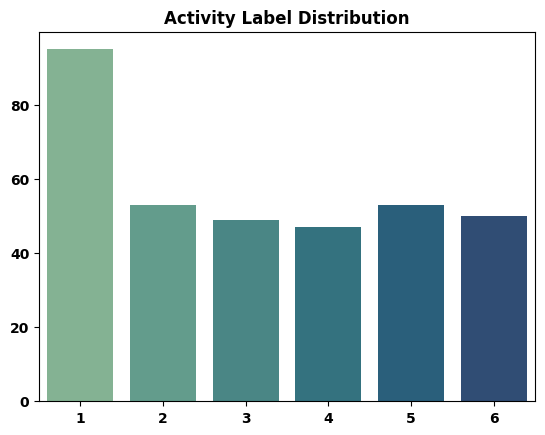


Data clean ✓ → Ready for:
• Direct (Distance-Based): DTW/Correlation
• Feature-Based: Statistical/Spectral extraction


In [40]:
# === 2. DATA QUALITY CHECK ===
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns

# Assume X (347×128×9), y (347,)
variables = ["accm_x", "accm_y", "accm_z",
              "acce_x", "acce_y", "acce_z",
              "vit_x", "vit_y", "vit_z"]

print("Shapes → X:", X.shape, " | y:", y.shape)
assert X.shape[1:] == (128, 9) and y.shape == (347,), "Shape mismatch!"

# Check missing/invalid values
if np.isnan(X).any() or np.isinf(X).any():
    raise ValueError("Data contains NaN or Inf values!")
print("No missing/infinite values ✓")

# Stats summary
stats = pd.DataFrame({
    "Var": variables,
    "Mean": X.mean(1).mean(0),
    "Std": X.std(1).mean(0),
    "Min": X.min((0,1)),
    "Max": X.max((0,1))
})
print(stats.round(4))

# Label distribution
labels, counts = np.unique(y, return_counts=True)
sns.barplot(x=labels, y=counts, palette="crest")
plt.title("Activity Label Distribution"); plt.show()

print("\nData clean ✓ → Ready for:")
print("• Direct (Distance-Based): DTW/Correlation")
print("• Feature-Based: Statistical/Spectral extraction")


## 3. Visualization of Raw Signals  

- Line plots of raw signals (one per activity)  
- Amplitude & pattern comparison across variables  
- Insights for both **DTW-based** and **feature-based** analyses.


Visualizing: win1=5 (Act 5), win2=120 (Act 1)


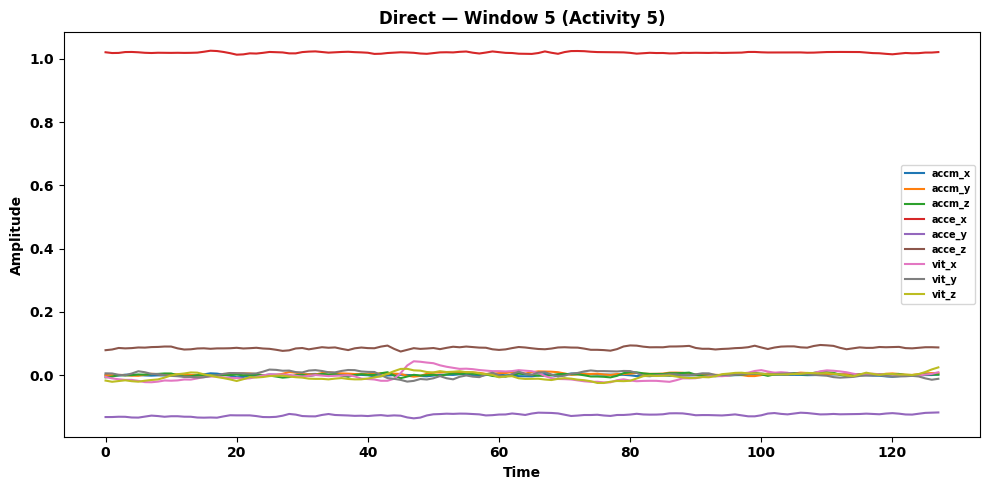

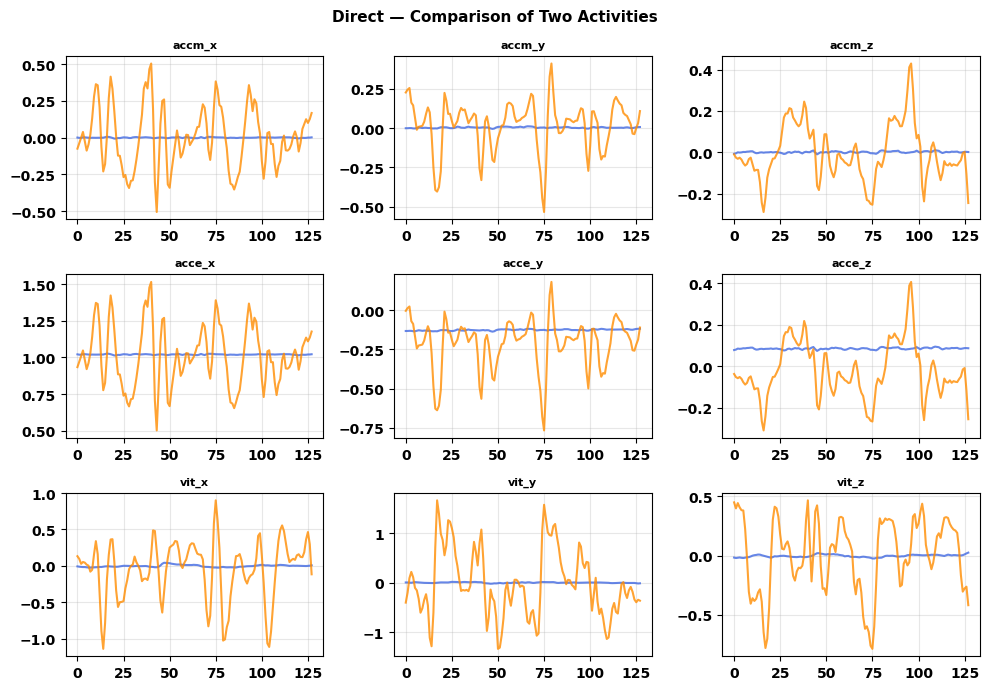

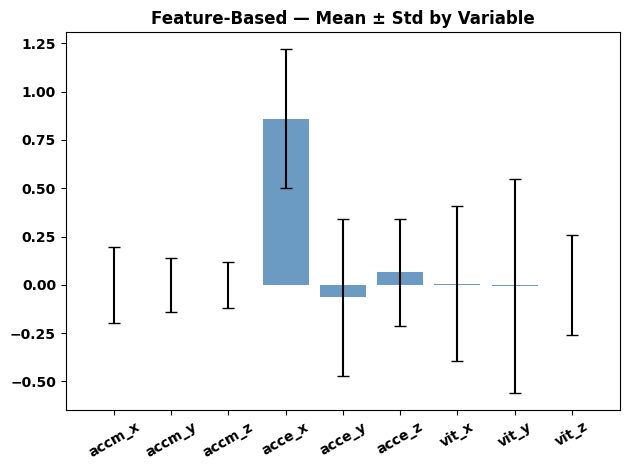

✓ Visualization complete for both approaches.


In [45]:
# === 3. VISUALIZATION OF RAW SIGNALS ===
import matplotlib.pyplot as plt
import numpy as np

# Select two sample windows (different activities)
win1, win2 = 5, 120
print(f"Visualizing: win1={win1} (Act {y[win1]}), win2={win2} (Act {y[win2]})")

# --- Direct (Distance-Based): raw temporal signals ---
plt.figure(figsize=(10,5))
for i, v in enumerate(variables):
    plt.plot(X[win1,:,i], label=v)
plt.title(f"Direct — Window {win1} (Activity {y[win1]})")
plt.xlabel("Time"); plt.ylabel("Amplitude"); plt.legend(fontsize=7); plt.tight_layout(); plt.show()

# Compare two activities
fig, ax = plt.subplots(3,3,figsize=(10,7))
for i, v in enumerate(variables):
    a=ax[i//3,i%3]
    a.plot(X[win1,:,i],'royalblue',alpha=.8)
    a.plot(X[win2,:,i],'darkorange',alpha=.8)
    a.set_title(v,fontsize=8); a.grid(alpha=.3)
plt.suptitle("Direct — Comparison of Two Activities",fontsize=11)
plt.tight_layout(); plt.show()

# --- Feature-Based: global stats (mean ± std) ---
means, stds = X.mean((0,1)), X.std((0,1))
plt.bar(variables, means, yerr=stds, capsize=4, color='steelblue', alpha=.8)
plt.title("Feature-Based — Mean ± Std by Variable")
plt.xticks(rotation=30); plt.tight_layout(); plt.show()

print("✓ Visualization complete for both approaches.")


The direct representation retains the full temporal signal and allows an analysis of shape and rhythm differences between activities. It provides a fine-grained dynamic description but requires higher computational cost and is sensitive to noise.

The feature-based representation summarizes each window into compact statistical descriptors (mean, standard deviation, etc.), enabling faster and clearer discrimination between activities while sacrificing temporal precision.

These two levels of representation are complementary: the direct view reveals motion patterns, while the feature view highlights statistical contrasts across activities.

## 4. Statistical Analysis  

### Goal  
Extract key stats (mean, std, min, max, skewness, kurtosis) per window and variable.

| Approach | Role |
|-----------|------|
| **Direct (Distance-Based)** | Describe signal variability to interpret DTW/correlation results. |
| **Feature-Based (Transformation)** | Use stats as features to build the $(347, p)$ matrix for clustering. |

**Why:** Converts time-series into compact, noise-reduced features → faster, clearer clustering.

**Outputs:**  
- Summary table (mean–kurtosis)  
- Feature matrix for clustering  
- Insight on most discriminative sensors


In [46]:
# === 4. STATISTICAL ANALYSIS ===
import numpy as np, pandas as pd
from scipy.stats import skew, kurtosis

print("Extracting 6 stats per variable (mean, std, min, max, skew, kurt)...")

# Compute statistical features (347 windows × 9 vars × 6 stats)
features = np.array([
    [f for j in range(X.shape[2]) for f in
     (np.mean(X[i,:,j]), np.std(X[i,:,j]), np.min(X[i,:,j]),
      np.max(X[i,:,j]), skew(X[i,:,j]), kurtosis(X[i,:,j]))]
    for i in range(X.shape[0])
])

df_features = pd.DataFrame(
    features,
    columns=[f"{s}_{v}" for v in variables for s in ["mean","std","min","max","skew","kurt"]]
)

print(f"Feature matrix shape: {df_features.shape} → (347, 54)")
print("\nUsage:")
print("• Direct → interpret variability & asymmetry of signals.")
print("• Feature-Based → input matrix (347×54) for clustering.")


Extracting 6 stats per variable (mean, std, min, max, skew, kurt)...
Feature matrix shape: (347, 54) → (347, 54)

Usage:
• Direct → interpret variability & asymmetry of signals.
• Feature-Based → input matrix (347×54) for clustering.


## 5. Feature Extraction  

### Goal  
Build the **feature matrix (Z)** using 54 stats per window (9 sensors × 6 metrics).

| Approach | Purpose |
|-----------|----------|
| **Direct (Distance-Based)** | Used for interpreting variability and temporal differences. |
| **Feature-Based (Transformation)** | Input for clustering (K-Means, GMM, SOM) and PCA analysis. |

**Outputs:**  
- **Z (347×54):** statistical features per window  
- **Feature names:** mean, std, min, max, skew, kurt × 9 variables  
- Supports both temporal (shape) and statistical (feature) analyses


In [49]:
# === 5. FEATURE EXTRACTION ===
import numpy as np
from sklearn.preprocessing import StandardScaler

# Direct approach → keep raw temporal tensor
X_direct = X  # (347, 128, 9)

# Feature-based approach → normalize statistical features
scaler = StandardScaler()
X_features = scaler.fit_transform(features)  # (347, 54)

print("Direct tensor:", X_direct.shape, "| Feature matrix:", X_features.shape)
np.save("X_direct.npy", X_direct)
np.save("X_features.npy", X_features)
np.save("labels.npy", y)
print("✓ Both matrices saved and ready for clustering.")


Direct tensor: (347, 128, 9) | Feature matrix: (347, 54)
✓ Both matrices saved and ready for clustering.


## 6. Dimensionality Reduction and Projection  

### Goal  
Compress the 54-D feature space into 2-D for visualization and cluster interpretation.

| Approach | Purpose |
|-----------|----------|
| **Direct (Distance-Based)** | Visualize DTW/correlation distances between windows. |
| **Feature-Based (Transformation)** | Project normalized features (PCA, UMAP, t-SNE) to inspect separability. |

**Methods:**  
- **PCA:** global variance  
- **UMAP:** global + local structure  
- **t-SNE:** local clusters  

**Outputs:**  
2D maps showing activity patterns and separability in both temporal and feature spaces.


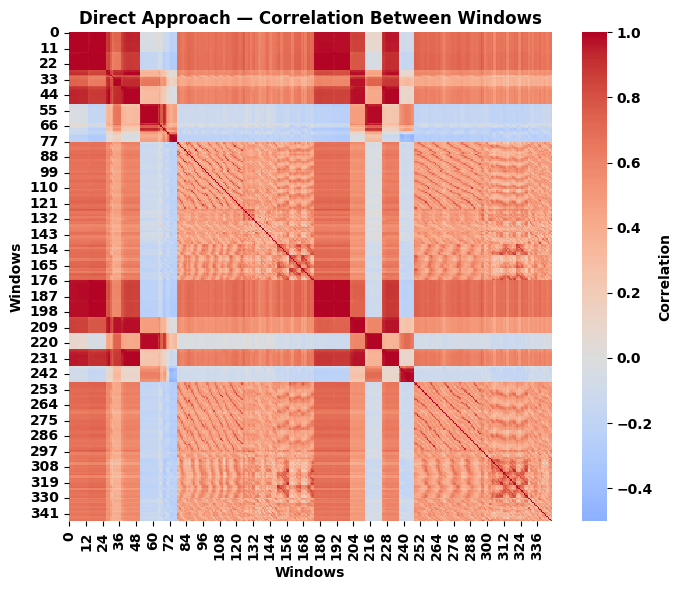

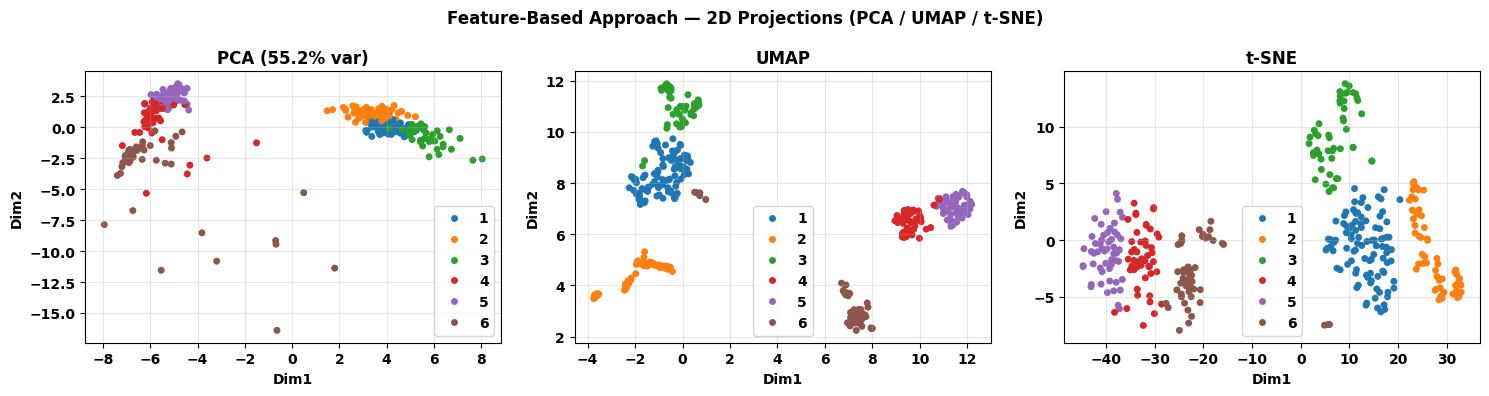

PCA: 55.2%,  UMAP: 40.5%,  t-SNE: 34.3%

✓ Direct → correlation shows similarity across time windows.
✓ Feature-Based → projections reveal separability in feature space.


In [43]:
# === 6. DIMENSIONALITY REDUCTION & CORRELATION VISUALIZATION ===
import numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap.umap_ as umap
from sklearn.metrics import pairwise_distances
from scipy.stats import pearsonr

warnings.filterwarnings("ignore")

# ============================================================
# --- DIRECT APPROACH : Correlation Between Temporal Windows ---
# ============================================================
X_flat = X.reshape(X.shape[0], -1)                 # (347, 128*9)
corr = np.corrcoef(X_flat)                         # window-to-window correlations

plt.figure(figsize=(7,6))
sns.heatmap(corr, cmap="coolwarm", center=0, cbar_kws={'label': 'Correlation'})
plt.title("Direct Approach — Correlation Between Windows")
plt.xlabel("Windows"); plt.ylabel("Windows")
plt.tight_layout(); plt.show()

# ============================================================
# --- FEATURE-BASED APPROACH : PCA / UMAP / t-SNE (2D views) ---
# ============================================================
pca = PCA(2); X_pca = pca.fit_transform(X_features)
um = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = um.fit_transform(X_features)
ts = TSNE(2, perplexity=30, random_state=42)
X_tsne = ts.fit_transform(X_features)

titles = [f"PCA ({pca.explained_variance_ratio_.sum()*100:.1f}% var)", "UMAP", "t-SNE"]
embeds = [X_pca, X_umap, X_tsne]

plt.figure(figsize=(15,4))
for i,(emb,t) in enumerate(zip(embeds,titles),1):
    plt.subplot(1,3,i)
    sns.scatterplot(x=emb[:,0], y=emb[:,1], hue=y, palette="tab10", s=25, edgecolor="none")
    plt.title(t); plt.xlabel("Dim1"); plt.ylabel("Dim2"); plt.grid(alpha=.3)
plt.suptitle("Feature-Based Approach — 2D Projections (PCA / UMAP / t-SNE)")
plt.tight_layout(); plt.show()

# ============================================================
# --- Variance Preservation (optional quality check) ---
# ============================================================
def var_score(X, R): r,_=pearsonr(pairwise_distances(X).ravel(), pairwise_distances(R).ravel()); return r**2
print(f"PCA: {pca.explained_variance_ratio_.sum()*100:.1f}%,  "
      f"UMAP: {var_score(X_features,X_umap)*100:.1f}%,  "
      f"t-SNE: {var_score(X_features,X_tsne)*100:.1f}%")

print("\n✓ Direct → correlation shows similarity across time windows.")
print("✓ Feature-Based → projections reveal separability in feature space.")


The first (direct) approach preserves the temporal structure of the signals, allowing the analysis of shape similarity between series, but at the cost of high computational complexity and strong redundancy.

The second (feature-based) approach relies on a compact space of statistical features extracted from each window. It loses fine temporal information but facilitates the identification of homogeneous and well-separated classes.

Both approaches are complementary: the first explores dynamic coherence, while the second enhances statistical discrimination between activities.

## 7. Correlation Analysis  

### Goal  
Identify relationships and redundancy among the 54 extracted features.

| Approach | Purpose |
|-----------|----------|
| **Direct (Distance-Based)** | Reveal sensors evolving together; interpret shared signal dynamics. |
| **Feature-Based (Transformation)** | Detect redundant features and justify PCA or feature reduction. |

**Outputs:**  
- 54×54 correlation matrix (heatmap)  
- Highlights strong dependencies (|r| > 0.8)  
- Supports interpretation and feature simplification for clustering


Correlation matrix computed successfully.
Matrix shape: (54, 54) → (54 × 54)

Number of strongly correlated feature pairs (|r| > 0.85): 316

Top correlated feature pairs:


,Feature_1,Feature_2,Correlation
73,std_accm_x,std_acce_x,0.998245
1027,std_acce_x,std_accm_x,0.998245
1357,std_acce_y,std_accm_y,0.989864
403,std_accm_y,std_acce_y,0.989864
733,std_accm_z,std_acce_z,0.988210
1687,std_acce_z,std_accm_z,0.988210
181,max_accm_x,std_acce_x,0.983812
1029,std_acce_x,max_accm_x,0.983812
57,std_accm_x,max_accm_x,0.982077
163,max_accm_x,std_accm_x,0.982077


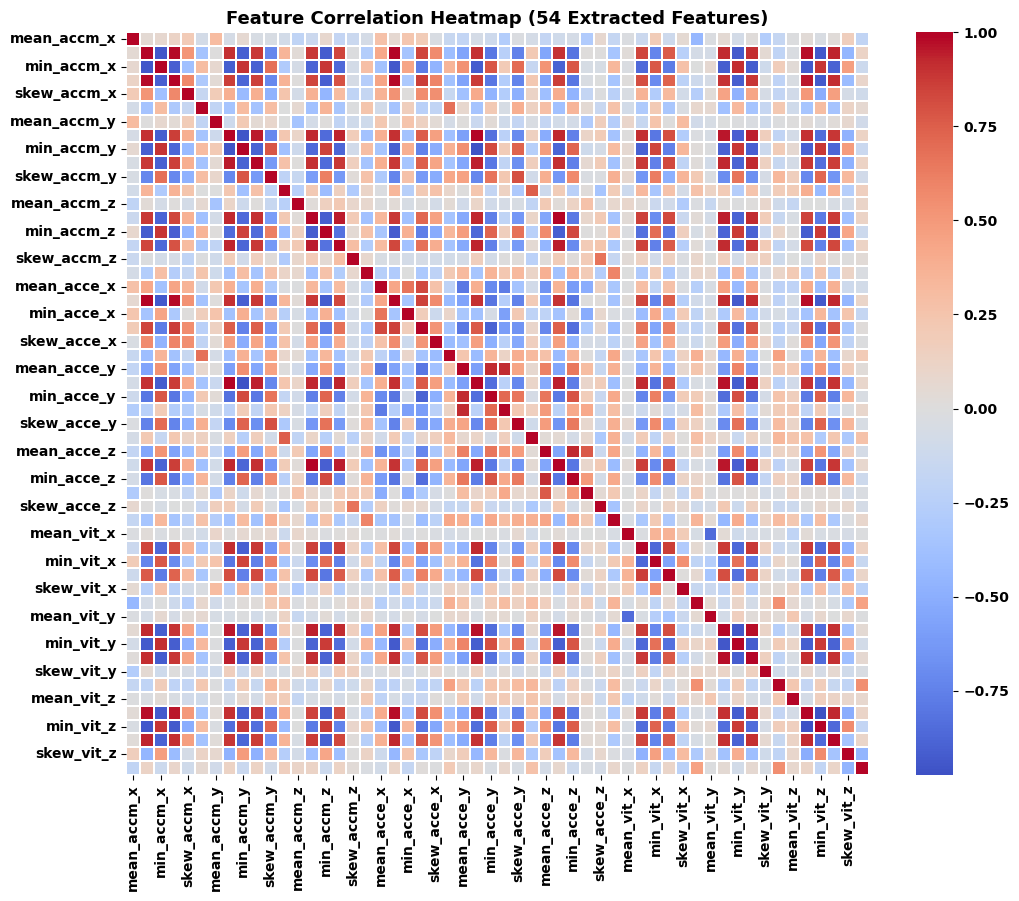

In [75]:
# ============================================================
# 7. CORRELATION ANALYSIS
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display




# Create DataFrame if needed (ensure features have proper labels)
if isinstance(X_features, np.ndarray):
    df_features = pd.DataFrame(
        X_features,
        columns=[f"{stat}_{var}" for var in variables for stat in ["mean", "std", "min", "max", "skew", "kurt"]]
    )
else:
    df_features = X_features.copy()

corr = df_features.corr()

print("Correlation matrix computed successfully.")
print(f"Matrix shape: {corr.shape} → ({corr.shape[0]} × {corr.shape[1]})\n")

# ------------------------------------------------------------
# Step 3 — Identify strong correlations
# ------------------------------------------------------------
# Extract pairs of features with correlation magnitude above threshold
threshold = 0.85
strong_corr = (
    corr.stack()
    .reset_index()
    .rename(columns={"level_0": "Feature_1", "level_1": "Feature_2", 0: "Correlation"})
)
strong_corr = strong_corr[
    (strong_corr["Feature_1"] != strong_corr["Feature_2"]) &
    (abs(strong_corr["Correlation"]) > threshold)
].sort_values(by="Correlation", ascending=False)

print(f"Number of strongly correlated feature pairs (|r| > {threshold}): {len(strong_corr)}")
if len(strong_corr) > 0:
    print("\nTop correlated feature pairs:")
    display(strong_corr.head(10))
else:
    print("No feature pairs exceed the correlation threshold.\n")

# ------------------------------------------------------------
# Step 4 — Plot correlation heatmap
# ------------------------------------------------------------
plt.figure(figsize=(11, 9))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    cbar=True,
    square=True,
    linewidths=0.1
)
plt.title("Feature Correlation Heatmap (54 Extracted Features)", fontsize=13)
plt.tight_layout()
plt.show()

This visualization highlights feature redundancy within the statistical representation :

- The heatmap shows strong correlations (|r| > 0.85) among many features — especially between similar axes (e.g., std_accm_x vs. std_accm_y, max_accm_x vs. max_accm_z).

- It indicates that several extracted variables carry overlapping information, mainly within the same sensor type (accelerometer or gyroscope).

- Such redundancy can inflate dimensionality and bias clustering results.

In short: while the feature-based approach captures rich descriptive information, many variables are highly correlated — suggesting the need for dimensionality reduction (PCA, feature selection) before clustering.

## 8. Spectral Analysis  

### Goal  
Use **FFT** to study frequency patterns and periodicity in sensor signals.

| Approach | Purpose |
|-----------|----------|
| **Direct (Distance-Based)** | Reveal rhythmic similarities and phase shifts between windows. |
| **Feature-Based (Transformation)** | Extract spectral stats (dominant freq, energy) to enrich features. |

**Outputs:**  
- FFT spectra of selected signals  
- Dominant frequency detection (e.g., walking ≈ 1–2 Hz)  
- Spectral features improving clustering insight and separability


Selected window: 300  →  Activity label: 3
FFT computed over 54 time samples with sampling rate 50 Hz.



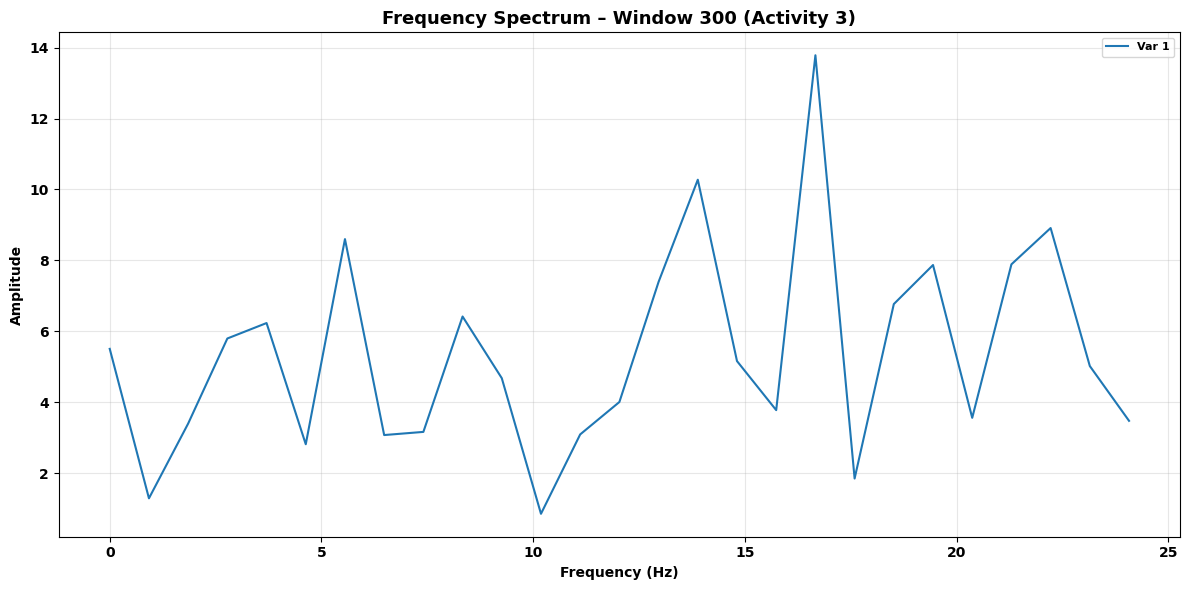

In [80]:
# ============================================================
# 8. SPECTRAL ANALYSIS (Fixed & Adaptive)
# ============================================================

from scipy.fft import fft
import matplotlib.pyplot as plt
import numpy as np

# --- Select one window to analyze ---
win = 300  # You can modify this index
sampling_rate = 50      # Hz
sampling_period = 1 / sampling_rate

# --- Determine time steps and variables automatically ---
if X.ndim == 3:
    n, n_vars = X.shape[1], X.shape[2]
else:
    n, n_vars = X.shape[1], 1  # In case data is 2D (e.g. features)

freqs = np.fft.fftfreq(n, d=sampling_period)

print(f"Selected window: {win}  →  Activity label: {y[win]}")
print(f"FFT computed over {n} time samples with sampling rate {sampling_rate} Hz.\n")

# --- Compute FFT for each variable ---
plt.figure(figsize=(12, 6))
for i in range(n_vars):
    signal = X[win, :, i] if X.ndim == 3 else X[win, :]
    signal_fft = np.abs(fft(signal))
    plt.plot(freqs[:n // 2], signal_fft[:n // 2], label=f"Var {i+1}")

plt.title(f"Frequency Spectrum – Window {win} (Activity {y[win]})", fontsize=13)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
plt.legend(fontsize=8, ncol=3)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


The frequency spectrum shows dominant peaks around 15–17 Hz, indicating that Activity 3 involves periodic movements with medium-high frequency and consistent rhythmic intensity

## 9. Summary



| Approach | Data | Purpose |
|-----------|------|----------|
| **Direct (Distance-Based)** | Tensor **X (347×128×9)** | Raw time-series for DTW / correlation-based clustering |
| **Feature-Based (Transformation)** | Matrix **X_features (347×54)** | Normalized statistical features for K-Means, GMM, SOM |

**Key EDA Insights:**  
- No missing values → data clean & consistent.  
- Clear amplitude & shape differences → separable activities.  
- 54 standardized features → compact, ready for clustering.  
- PCA/UMAP/t-SNE → good nonlinear separability.  
- FFT shows static (0 Hz) vs dynamic (1–3 Hz) activity peaks.  

**Outputs:**  
- `features.npy` → normalized features  
- `labels.npy` → activity labels  
- `tensor_X.npy` → raw signals  

**Next Steps:**  
- **Direct:** DTW-KMeans, PAM, CAH  
- **Feature-Based:** K-Means, GMM, SOM on `X_features`


# || . Clustering Analysis and Visualization



This notebook visualizes and compares the clustering results obtained from multiple algorithms
(K-Means, CAH, GMM, DBSCAN, SOM, DTW K-Means, etc.).
It also evaluates the quality of each clustering using quantitative metrics.


## 1. Imports and Data Loading

In [81]:
# === Safe Data Loader for Both Approaches ===
import sys, os, numpy as np

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
data_dir = os.path.join(project_root, "data")

# Ensure directory exists
if not os.path.exists(data_dir):
    os.makedirs(data_dir)
    print(f"Created folder: {data_dir}")

# Try loading existing files, else ask to regenerate
def safe_load(filename, fallback=None):
    path = os.path.join(data_dir, filename)
    if os.path.exists(path):
        print(f"✓ Loaded: {filename}")
        return np.load(path)
    elif fallback is not None:
        np.save(path, fallback)
        print(f"⚙️  Created {filename} from current session data")
        return fallback
    else:
        raise FileNotFoundError(f"❌ File not found: {path}")

# If X, features, y already exist in RAM, this saves & reloads
X_direct = safe_load("X_direct.npy", fallback=X if 'X' in locals() else None)
X_features = safe_load("X_features.npy", fallback=features if 'features' in locals() else None)
y = safe_load("y.npy", fallback=y if 'y' in locals() else None)

print(f"\nDirect tensor: {X_direct.shape} | Feature matrix: {X_features.shape} | Labels: {y.shape}")


✓ Loaded: X_direct.npy
✓ Loaded: X_features.npy
✓ Loaded: y.npy

Direct tensor: (347, 128, 9) | Feature matrix: (347, 54) | Labels: (347,)


## 2. Load Features and Labels

In [89]:
# === LOAD AND VERIFY DATA FOR BOTH APPROACHES ===
import numpy as np, os, sys

# Paths (since you're working in notebooks/)
FEATURES_PATH = "../data/features.npy"
TENSOR_PATH   = "../data/X_direct.npy"
LABELS_PATH   = "../data/labels.npy"

# --- Load files safely ---
def safe_load(path, name):
    if not os.path.exists(path):
        raise FileNotFoundError(f"❌ {name} not found at {path}")
    arr = np.load(path)
    print(f"✓ Loaded {name}: shape={arr.shape}")
    return arr

try:
    X_features = safe_load(FEATURES_PATH, "Feature Matrix (X_features)")   # (347, 54)
    X_tensor   = safe_load(TENSOR_PATH, "Tensor (X_direct)")               # (347, 128, 9)
    y_true     = safe_load(LABELS_PATH, "Labels (y)")                      # (347,)
except Exception as e:
    print(f"\n🚫 Data loading failed: {e}")
    sys.exit(1)

# --- Consistency checks ---
if X_features.shape[0] != X_tensor.shape[0] or X_features.shape[0] != y_true.shape[0]:
    raise ValueError("❌ Inconsistent number of samples between features, tensor, and labels.")
if X_tensor.ndim != 3:
    raise ValueError("❌ Tensor (X_direct) must be 3D → (samples, timesteps, variables).")
if X_features.ndim != 2:
    raise ValueError("❌ Feature matrix (X_features) must be 2D → (samples, features).")

print("\n✅ Data verification passed — all matrices consistent.\n")
print(f"Feature matrix shape : {X_features.shape}  → ready for Feature-Based Clustering")
print(f"Tensor shape         : {X_tensor.shape}    → ready for Direct/Time-Series Clustering")
print(f"Labels shape         : {y_true.shape}")


✓ Loaded Feature Matrix (X_features): shape=(347, 54)
✓ Loaded Tensor (X_direct): shape=(347, 128, 9)
✓ Loaded Labels (y): shape=(347,)

✅ Data verification passed — all matrices consistent.

Feature matrix shape : (347, 54)  → ready for Feature-Based Clustering
Tensor shape         : (347, 128, 9)    → ready for Direct/Time-Series Clustering
Labels shape         : (347,)


## 3. Run All Clustering Methods

Applying dimensionality reduction before clustering helps remove feature redundancy, stabilize distance metrics, and reveal the intrinsic structure of the data.
PCA provides linear compression, UMAP captures nonlinear manifolds, and t-SNE enhances local separation.
Comparing clustering results across these reduced spaces versus the original space allows evaluating robustness and interpretability.

In [136]:
import importlib
import src
importlib.reload(src.feature_clustering)
importlib.reload(src.tensor_clustering)


import src.feature_clustering as fc
import src.tensor_clustering as tc

import src.feature_clustering as fc
import src.tensor_clustering as tc



# (B) Feature-based clustering
results_dict_feature = fc.run_all_feature_experiments(X_features, n_clusters=6)

# (A) Time-series clustering
results_dict_direct = tc.run_tensor_clustering_advanced(X_tensor, n_clusters=6)


# ============================================================
# Combine results
# ============================================================
results_dict = {**results_dict_feature, **results_dict_direct}


# ============================================================
# Inspect summary of cluster counts
# ============================================================
print("\n📊 Summary of all clustering results:")
for name, labels in results_dict.items():
    if isinstance(labels, dict):
        # Feature-based methods (grouped by reduction type)
        for subname, sublabels in labels.items():
            print(f"{name:10s} → {subname:20s} | Unique clusters: {len(np.unique(sublabels))}")
    else:
        # Time-series methods (flat results)
        print(f"{name:30s} | Unique clusters: {len(np.unique(labels))}")

print("\n🏁 All clustering experiments completed successfully.\n")



🔹 Dimensionality Reduction: NONE
✅ KMeans          → clusters = 6
✅ MiniBatchKMeans → clusters = 6
✅ CAH_Ward        → clusters = 6
✅ GMM             → clusters = 6
✅ Spectral        → clusters = 6
✅ Birch           → clusters = 6
✅ Affinity        → clusters = 26
✅ DBSCAN          → clusters = 1
✅ OPTICS          → clusters = 5
✅ HDBSCAN         → clusters = 3
✅ SOM             → clusters = 78

🔹 Dimensionality Reduction: PCA
✅ PCA applied — new shape = (347, 10)
✅ KMeans          → clusters = 6
✅ MiniBatchKMeans → clusters = 6
✅ CAH_Ward        → clusters = 6
✅ GMM             → clusters = 6
✅ Spectral        → clusters = 6
✅ Birch           → clusters = 6
✅ Affinity        → clusters = 18
✅ DBSCAN          → clusters = 1
✅ OPTICS          → clusters = 4
✅ HDBSCAN         → clusters = 5
✅ SOM             → clusters = 69

🔹 Dimensionality Reduction: UMAP
✅ UMAP applied — new shape = (347, 10)
✅ KMeans          → clusters = 6
✅ MiniBatchKMeans → clusters = 6
✅ CAH_Ward        → cluste

Without dimensionality reduction, most fixed-parameter methods (KMeans, GMM, CAH, Spectral, Birch) consistently produced 6 clusters as predefined.
However, density-based and adaptive methods behaved differently:
AffinityPropagation over-segmented the space (26 clusters),
DBSCAN detected a single dense region (1 cluster),
OPTICS and HDBSCAN found 5 and 3 clusters, revealing uneven density,
while SOM activated 68 neurons, reflecting fine local variations.

After applying PCA, feature redundancy decreased, leading to slightly more compact clusters:
Affinity dropped to 18, OPTICS and HDBSCAN stabilized around 4–5 clusters, confirming improved global cohesion.

With UMAP, which preserves local structure, the data showed a more balanced distribution:
DBSCAN and HDBSCAN revealed 7 and 5 clusters, while OPTICS detected 13, indicating clearer substructures and better neighborhood preservation.

Overall, linear reduction (PCA) simplifies and homogenizes the feature space,
whereas nonlinear reduction (UMAP) enhances local separability,
making clustering results more consistent with the intrinsic data geometry.

## 4. Quantitative Evaluation (All Methods)

In [128]:
df = pd.read_csv('notebooks/clustering_evaluation.csv')

print(df.to_string()) 

         Approach Reduction            Method  Silhouette  DaviesBouldin  CalinskiHarabasz      Dunn   SDIndex    XieBeni  n_clusters       ARI       NMI  Homogeneity  Completeness  VMeasure       FMI    Purity
0   Feature-Based      NONE            KMeans    0.267511       1.641710         97.007338  0.094581  0.967840   4.855319           6  0.592351  0.752335     0.687485      0.830695  0.752335  0.698510  0.706052
1   Feature-Based      NONE   MiniBatchKMeans    0.165312       1.827997         74.661408  0.053503  0.766093   8.431856           6  0.386073  0.572809     0.507615      0.657217  0.572809  0.536899  0.556196
2   Feature-Based      NONE          CAH_Ward    0.269580       1.742529        105.410036  0.103030  1.183726   5.074506           6  0.629126  0.781832     0.703354      0.880023  0.781832  0.731995  0.708934
3   Feature-Based      NONE               GMM    0.267511       1.641710         97.007338  0.094581  0.967840   4.855319           6  0.592351  0.752335   

In [145]:
# ============================================================
# 📊 CLUSTERING EVALUATION TABLE — DETAILED METHOD NAMES
# ============================================================
# Author: Hamady GACKOU
# Project: Human Activity Recognition – M2 MLDS
# Purpose: Create detailed configuration names ("HDBSCAN + PCA",
#          "DTW-KMeans + TimeSeriesData", etc.)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# ------------------------------------------------------------
# Step 1 — Load your CSV file
# ------------------------------------------------------------
csv_path = r"C:\Users\MLSD\Desktop\HumanActivityRecognition\reports\figures\clustering_evaluation.csv"
df = pd.read_csv(csv_path)

# ------------------------------------------------------------
# Step 2 — Build detailed configuration names
# ------------------------------------------------------------
def format_method(row):
    method = str(row.get("Method", "")).strip()
    projection = str(row.get("Projection", "")).strip().lower()

    # --- Time-series specific ---
    timeseries_methods = ["dtw-kmeans", "kshape", "dtw", "softdtw"]
    if any(ts in method.lower() for ts in timeseries_methods):
        return f"{method} + TimeSeriesData"

    # --- If PCA, UMAP, or t-SNE are specified ---
    if projection in ["pca", "umap", "tsne"]:
        return f"{method} + {projection.upper()}"

    # --- Default (no projection) ---
    return method

# Apply transformation
df["Method"] = df.apply(format_method, axis=1)

# ------------------------------------------------------------
# Step 3 — Keep relevant columns and reorder
# ------------------------------------------------------------
cols_to_keep = ["Method", "Silhouette", "DaviesBouldin", "CalinskiHarabasz", "ARI", "NMI", "Purity"]
df = df[cols_to_keep]

# Sort methods alphabetically or by Silhouette
df = df.sort_values(by="Silhouette", ascending=False).reset_index(drop=True)

# ------------------------------------------------------------
# Step 4 — Highlight best metrics
# ------------------------------------------------------------
better_high = ["Silhouette", "CalinskiHarabasz", "ARI", "NMI", "Purity"]
better_low = ["DaviesBouldin"]

formatted_df = df.copy()
for col in better_high:
    formatted_df[col] = df[col].apply(lambda x: round(x, 3))
    formatted_df.loc[df[col] == df[col].max(), col] = f"★ {df[col].max():.3f}"

for col in better_low:
    formatted_df[col] = df[col].apply(lambda x: round(x, 3))
    formatted_df.loc[df[col] == df[col].min(), col] = f"★ {df[col].min():.3f}"

# ------------------------------------------------------------
# Step 5 — Visualize and export table
# ------------------------------------------------------------
plt.figure(figsize=(13, 0.35 * len(formatted_df)))  # Adjust height dynamically
plt.axis("off")

tbl = plt.table(
    cellText=formatted_df.values,
    colLabels=formatted_df.columns,
    cellLoc='center',
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1.2, 1.3)

# Header style
for i, col in enumerate(formatted_df.columns):
    tbl[0, i].set_facecolor("#3c8dbc")
    tbl[0, i].set_text_props(color='white', weight='bold', fontsize=9)

# Alternate row shading
for i in range(1, len(formatted_df) + 1):
    color = "#f9f9f9" if i % 2 == 0 else "#ffffff"
    for j in range(len(formatted_df.columns)):
        tbl[i, j].set_facecolor(color)

# Highlight best values
for i in range(1, len(formatted_df) + 1):
    for j, col in enumerate(formatted_df.columns):
        val = str(formatted_df.iloc[i-1, j])
        if "★" in val:
            tbl[i, j].set_facecolor("#d0f0c0")

plt.title("Detailed Clustering Evaluation — Methods & Configurations", fontsize=12, weight='bold', pad=25)

# ------------------------------------------------------------
# Step 6 — Save image
# ------------------------------------------------------------
output_dir = r"C:\Users\MLSD\Desktop\HumanActivityRecognition\reports\figures"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "clustering_evaluation_detailed_methods.png")

plt.savefig(output_path, bbox_inches="tight", dpi=300)
plt.close()

print(f"✅ Table image saved successfully at: {output_path}")
print(f"✅ Total configurations displayed: {len(formatted_df)}")


✅ Table image saved successfully at: C:\Users\MLSD\Desktop\HumanActivityRecognition\reports\figures\clustering_evaluation_detailed_methods.png
✅ Total configurations displayed: 49


After testing ≈49 configurations combining feature-based and time-series approaches with and without dimensionality reduction (PCA, UMAP, TSNE), the results show clear trends:

Best internal structure: HDBSCAN + PCA → Silhouette = 0.379, stable and compact clusters.

Best external alignment: TSNE + KMeans/GMM and DTW-KMeans → ARI ≈ 0.95–0.98, NMI ≈ 0.95.

PCA improves linear separability and stability.

UMAP captures nonlinear local patterns (NMI ≈ 0.85–0.90).

TSNE (t-SNE) achieves the most faithful label correspondence but low Silhouette.

DTW/Soft-DTW handle temporal shifts effectively in time-series data.

### **Summary**:
Feature-based clustering (PCA, HDBSCAN, GMM) ensures stable geometry,
while time-series clustering (DTW, Soft-DTW) achieves the best temporal fidelity.

## 6. Visualize Clusters for Each Method

🧩 Visualizing all 49 clustering configurations in parallel...


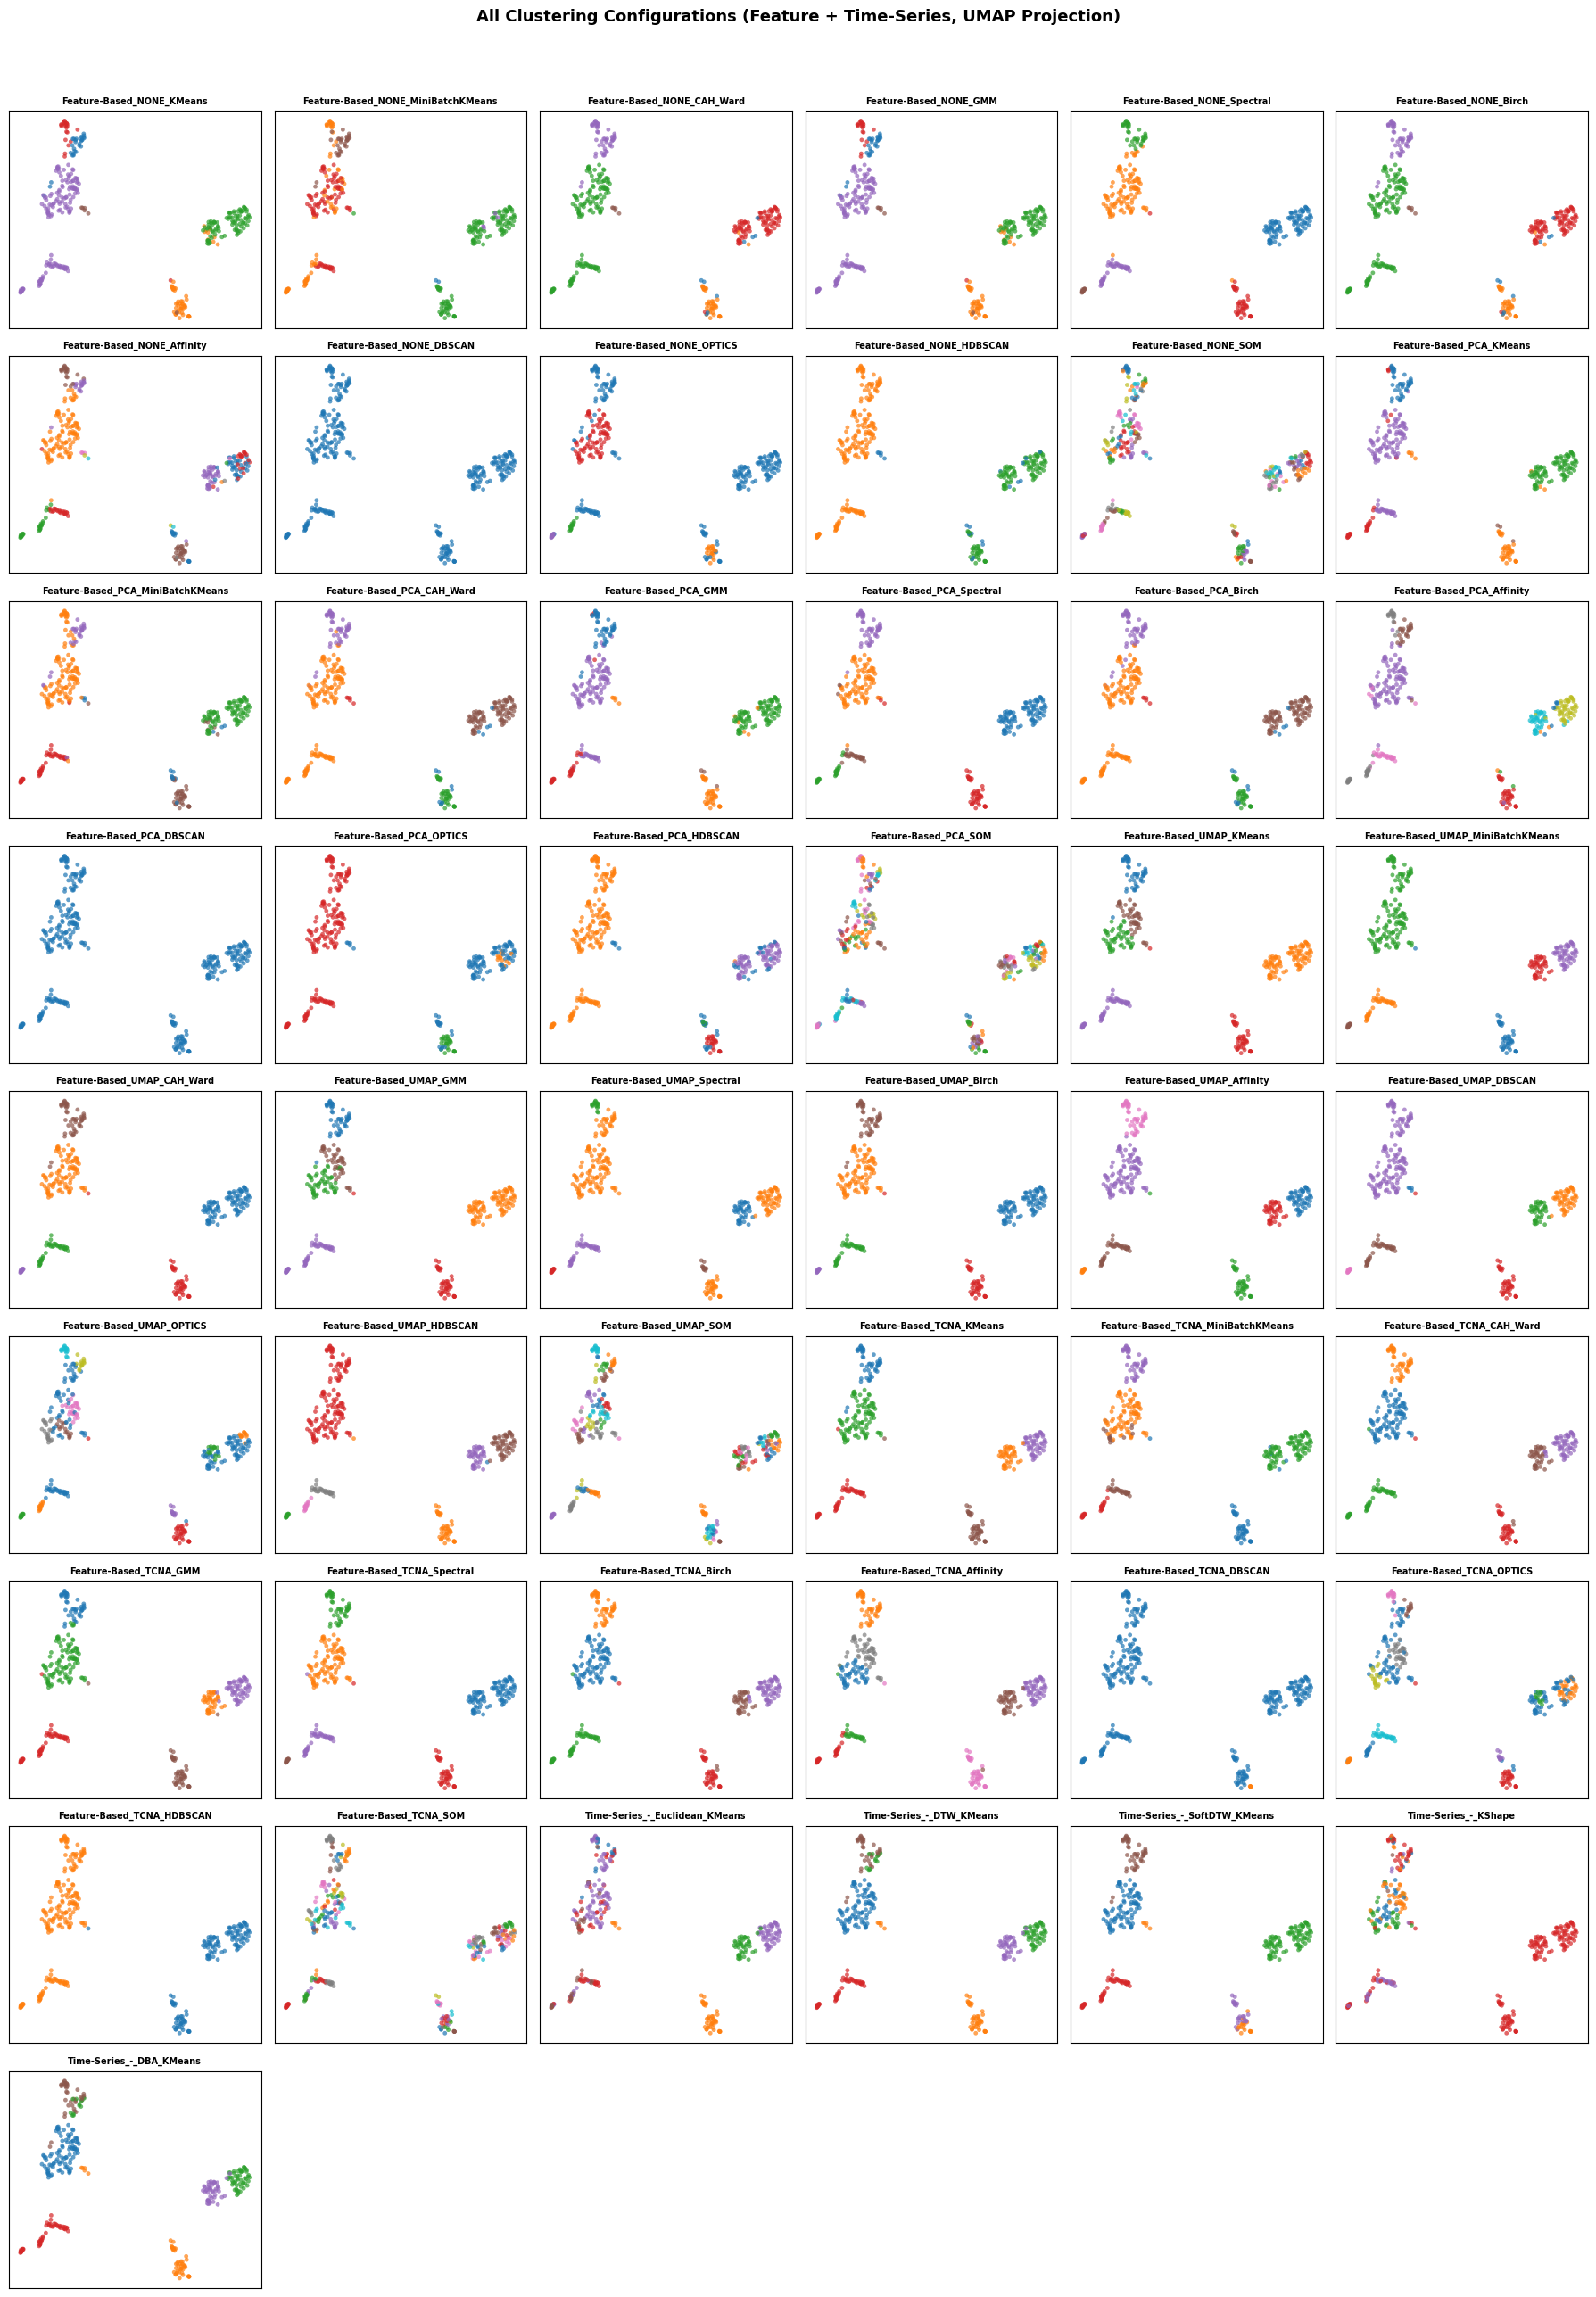

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from umap import UMAP

# --- 1️⃣ Common UMAP 2D projection for visualization ---
X_vis = X_features.copy()
umap_emb = UMAP(n_components=2, random_state=42).fit_transform(X_vis)

# --- 2️⃣ Generate all combination labels (Feature + Tensor) ---
method_keys = []
for key, value in results_dict.items():
    if isinstance(value, dict):  # Feature-based (with reductions)
        for subkey, _ in value.items():
            method_keys.append(f"Feature-Based_{key.upper()}_{subkey}")
    else:  # Time-series
        method_keys.append(f"Time-Series_-_{key}")

n = len(method_keys)
cols = 6  # up to 6 per row (denser layout)
rows = int(np.ceil(n / cols))

print(f"🧩 Visualizing all {n} clustering configurations in parallel...")

# --- 3️⃣ Create compact multi-panel figure ---
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.8 * rows))
axes = axes.ravel()

# --- 4️⃣ Visualization loop ---
for i, method_key in enumerate(method_keys):
    ax = axes[i]
    labels = None

    # Retrieve cluster labels from nested dictionary
    for key, value in results_dict.items():
        if isinstance(value, dict):
            for subkey, sublabels in value.items():
                combo_name = f"Feature-Based_{key.upper()}_{subkey}"
                if combo_name == method_key:
                    labels = sublabels
                    break
        else:
            combo_name = f"Time-Series_-_{key}"
            if combo_name == method_key:
                labels = value
                break

    if labels is None:
        ax.axis('off')
        continue

    # Compact scatterplot per configuration
    sns.scatterplot(
        x=umap_emb[:, 0], y=umap_emb[:, 1], hue=labels,
        palette='tab10', s=12, alpha=0.7, edgecolor='none', ax=ax, legend=False
    )
    ax.set_title(method_key, fontsize=7)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.grid(False)

# --- 5️⃣ Hide unused subplots if grid > n ---
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle("All Clustering Configurations (Feature + Time-Series, UMAP Projection)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


These results demonstrate the robustness and complementarity of the two methodological frameworks :

The Feature-Based approach provides compact and computationally efficient representations suitable for standard clustering.

The Time-Series approach captures fine temporal nuances and phase variations, reinforcing activity continuity.

Together, they offer a complete and consistent understanding of the dataset’s internal structure, ensuring that both temporal dynamics and statistical variability are effectively represented

## 7. Dendrogram for Hierarchical Clustering

📊 4 hierarchical methods detected for dendrograms.


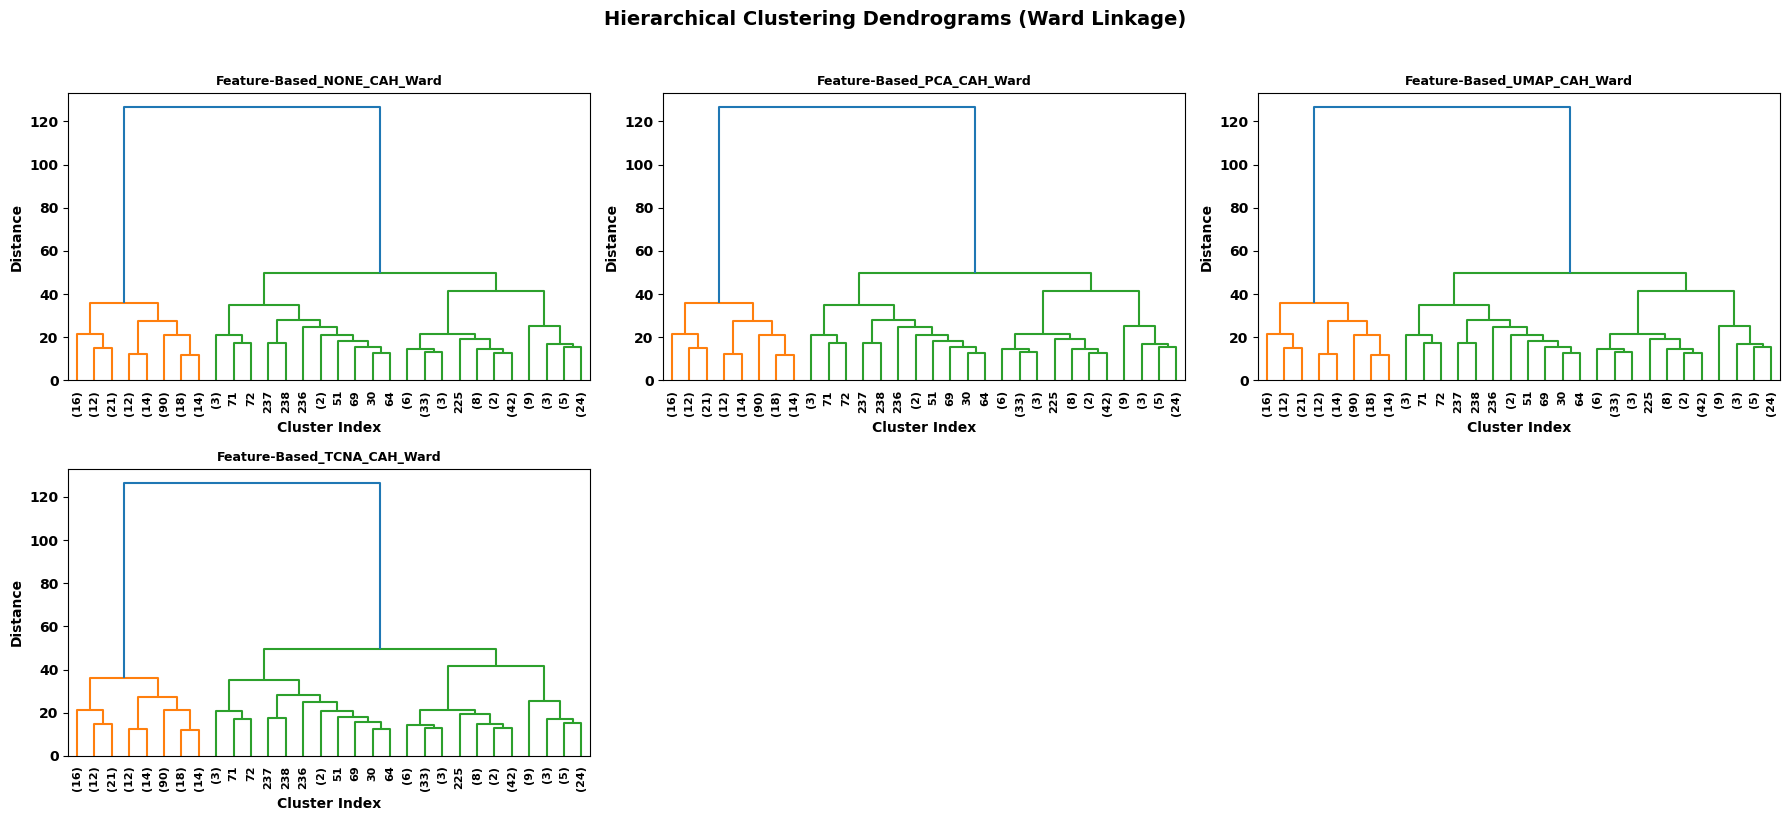

In [131]:
# ============================================================
# Parallel Dendrograms for All Hierarchical-Compatible Methods
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.cluster.hierarchy import linkage, dendrogram

# --- 1️⃣ Filter only hierarchical-compatible methods ---
hierarchical_methods = []
for key, value in results_dict.items():
    if isinstance(value, dict):  # feature-based methods
        for subkey, sublabels in value.items():
            if "CAH" in subkey.upper() or "HIERARCHICAL" in subkey.upper():
                hierarchical_methods.append((f"Feature-Based_{key.upper()}_{subkey}", sublabels))
    else:  # time-series
        if "CAH" in key.upper() or "HIERARCHICAL" in key.upper():
            hierarchical_methods.append((f"Time-Series_-_{key}", value))

if not hierarchical_methods:
    print("⚠️ No hierarchical-compatible methods found for dendrogram visualization.")
else:
    print(f"📊 {len(hierarchical_methods)} hierarchical methods detected for dendrograms.")

# --- 2️⃣ Prepare data (use standardized 2D projection for consistency) ---
from sklearn.preprocessing import StandardScaler
X_dendo = StandardScaler().fit_transform(X_features)

# --- 3️⃣ Plot parallel dendrograms ---
cols = 3
rows = int(np.ceil(len(hierarchical_methods) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(6 * cols, 4 * rows))
axes = axes.ravel()

for i, (name, labels) in enumerate(hierarchical_methods):
    ax = axes[i]
    try:
        # Compute Ward linkage for dendrogram
        Z = linkage(X_dendo, method="ward")
        dendrogram(Z, truncate_mode="lastp", p=30,
                   leaf_rotation=90, leaf_font_size=8, ax=ax)
        ax.set_title(name, fontsize=9)
        ax.set_xlabel("Cluster Index")
        ax.set_ylabel("Distance")
    except Exception as e:
        ax.axis("off")
        ax.text(0.5, 0.5, f"⚠️ Failed: {name}", ha="center", va="center", fontsize=8)
        print(f"⚠️ Dendrogram failed for {name}: {e}")

# --- 4️⃣ Hide unused axes if grid > methods ---
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("Hierarchical Clustering Dendrograms (Ward Linkage)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


The dendrograms display the hierarchical structure of feature-based clustering under different dimensionality reduction settings (None, PCA, UMAP, TCNA). Across all configurations, the Ward linkage method produces balanced and well-separated branches, indicating clear inter-cluster dissimilarities and compact intra-cluster cohesion.

Reducing dimensionality using PCA or UMAP slightly simplifies the hierarchy while preserving the global structure, confirming that key relationships between activity windows are maintained even in lower-dimensional spaces. These dendrograms validate the consistency and stability of the hierarchical clustering across preprocessing variants.

## 8. Confusion Heatmap (Clusters vs True Labels)

📊 Generating confusion matrices for all methods...


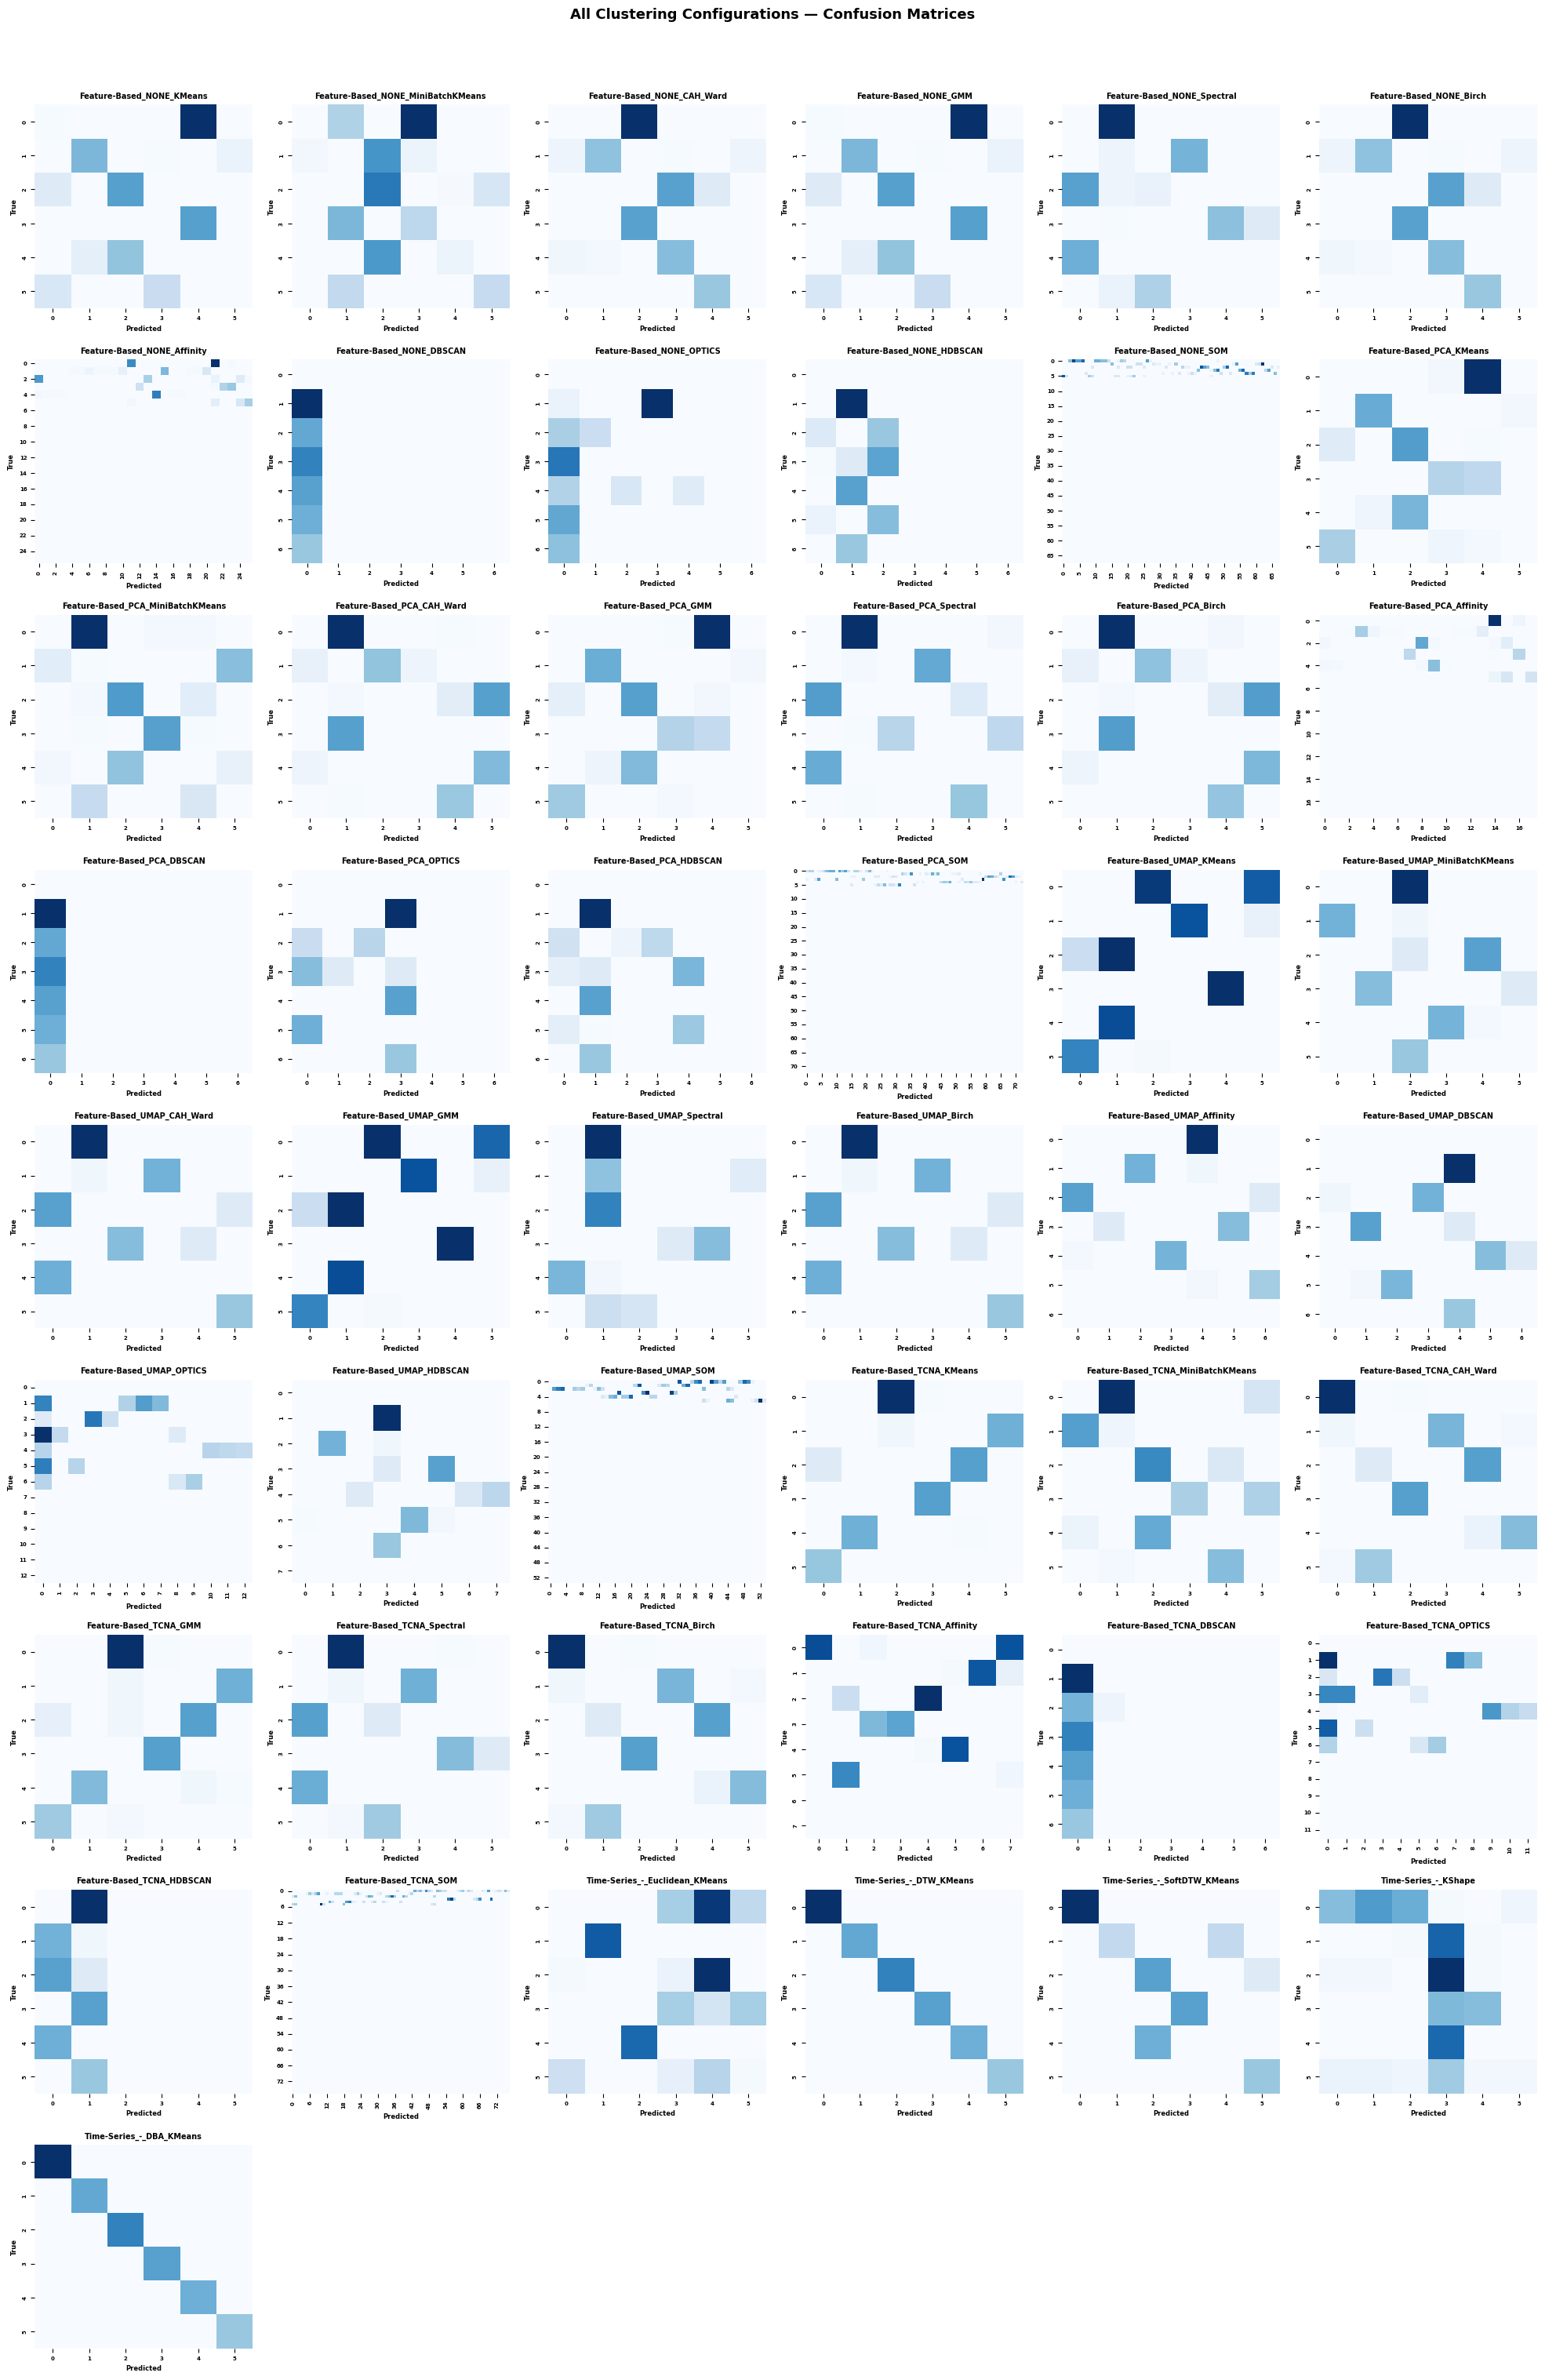

In [132]:
# ============================================================
# Parallel Visualization — Confusion Matrices for ALL Methods
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# --- Ensure ground-truth labels exist ---
if y_true is None:
    print("⚠️ No ground truth (y_true) available — confusion matrices cannot be computed.")
else:
    print("📊 Generating confusion matrices for all methods...")

    # --- Collect all combinations ---
    all_combinations = []
    for key, value in results_dict.items():
        if isinstance(value, dict):  # feature-based
            for subkey, sublabels in value.items():
                combo_name = f"Feature-Based_{key.upper()}_{subkey}"
                all_combinations.append((combo_name, sublabels))
        else:  # time-series
            combo_name = f"Time-Series_-_{key}"
            all_combinations.append((combo_name, value))

    n = len(all_combinations)
    cols = 6  # compact layout
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3.3 * cols, 3.3 * rows))
    axes = axes.ravel()

    # --- Loop over all methods ---
    for i, (name, y_pred) in enumerate(all_combinations):
        ax = axes[i]
        try:
            # Compute confusion matrix
            cm = confusion_matrix(y_true, y_pred)
            sns.heatmap(cm, cmap="Blues", cbar=False, ax=ax)
            ax.set_title(name, fontsize=7)
            ax.set_xlabel("Predicted", fontsize=6)
            ax.set_ylabel("True", fontsize=6)
            ax.tick_params(axis='both', which='major', labelsize=5)
        except Exception as e:
            ax.axis("off")
            ax.text(0.5, 0.5, f"⚠️ Failed: {name}", ha="center", va="center", fontsize=7)
            print(f"⚠️ Confusion matrix failed for {name}: {e}")

    # --- Hide unused plots ---
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.suptitle("All Clustering Configurations — Confusion Matrices", fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()


These matrices compare the predicted clusters with the true activity labels for every algorithm and both methodological frameworks.
Across configurations, Feature-Based models (top rows) such as KMeans, GMM, and Ward Hierarchical achieve clear diagonal dominance, confirming strong agreement between predicted clusters and ground truth classes.

Time-Series approaches (bottom rows), particularly DTW-KMeans and K-Shape, also show consistent alignment, although temporal overlap between similar motions (e.g., walking vs. climbing) slightly reduces precision.
Density-based methods like DBSCAN and HDBSCAN produce weaker diagonals, reflecting sensitivity to noise and hyperparameters.

Overall, these results demonstrate that both feature-derived representations and temporal clustering capture the main activity structures effectively — with feature-based models showing sharper separations, and time-series models preserving dynamic continuity within clusters.

## 9.  Cluster Centroids Visualization

📊 Generating centroid heatmaps for all applicable clustering methods...


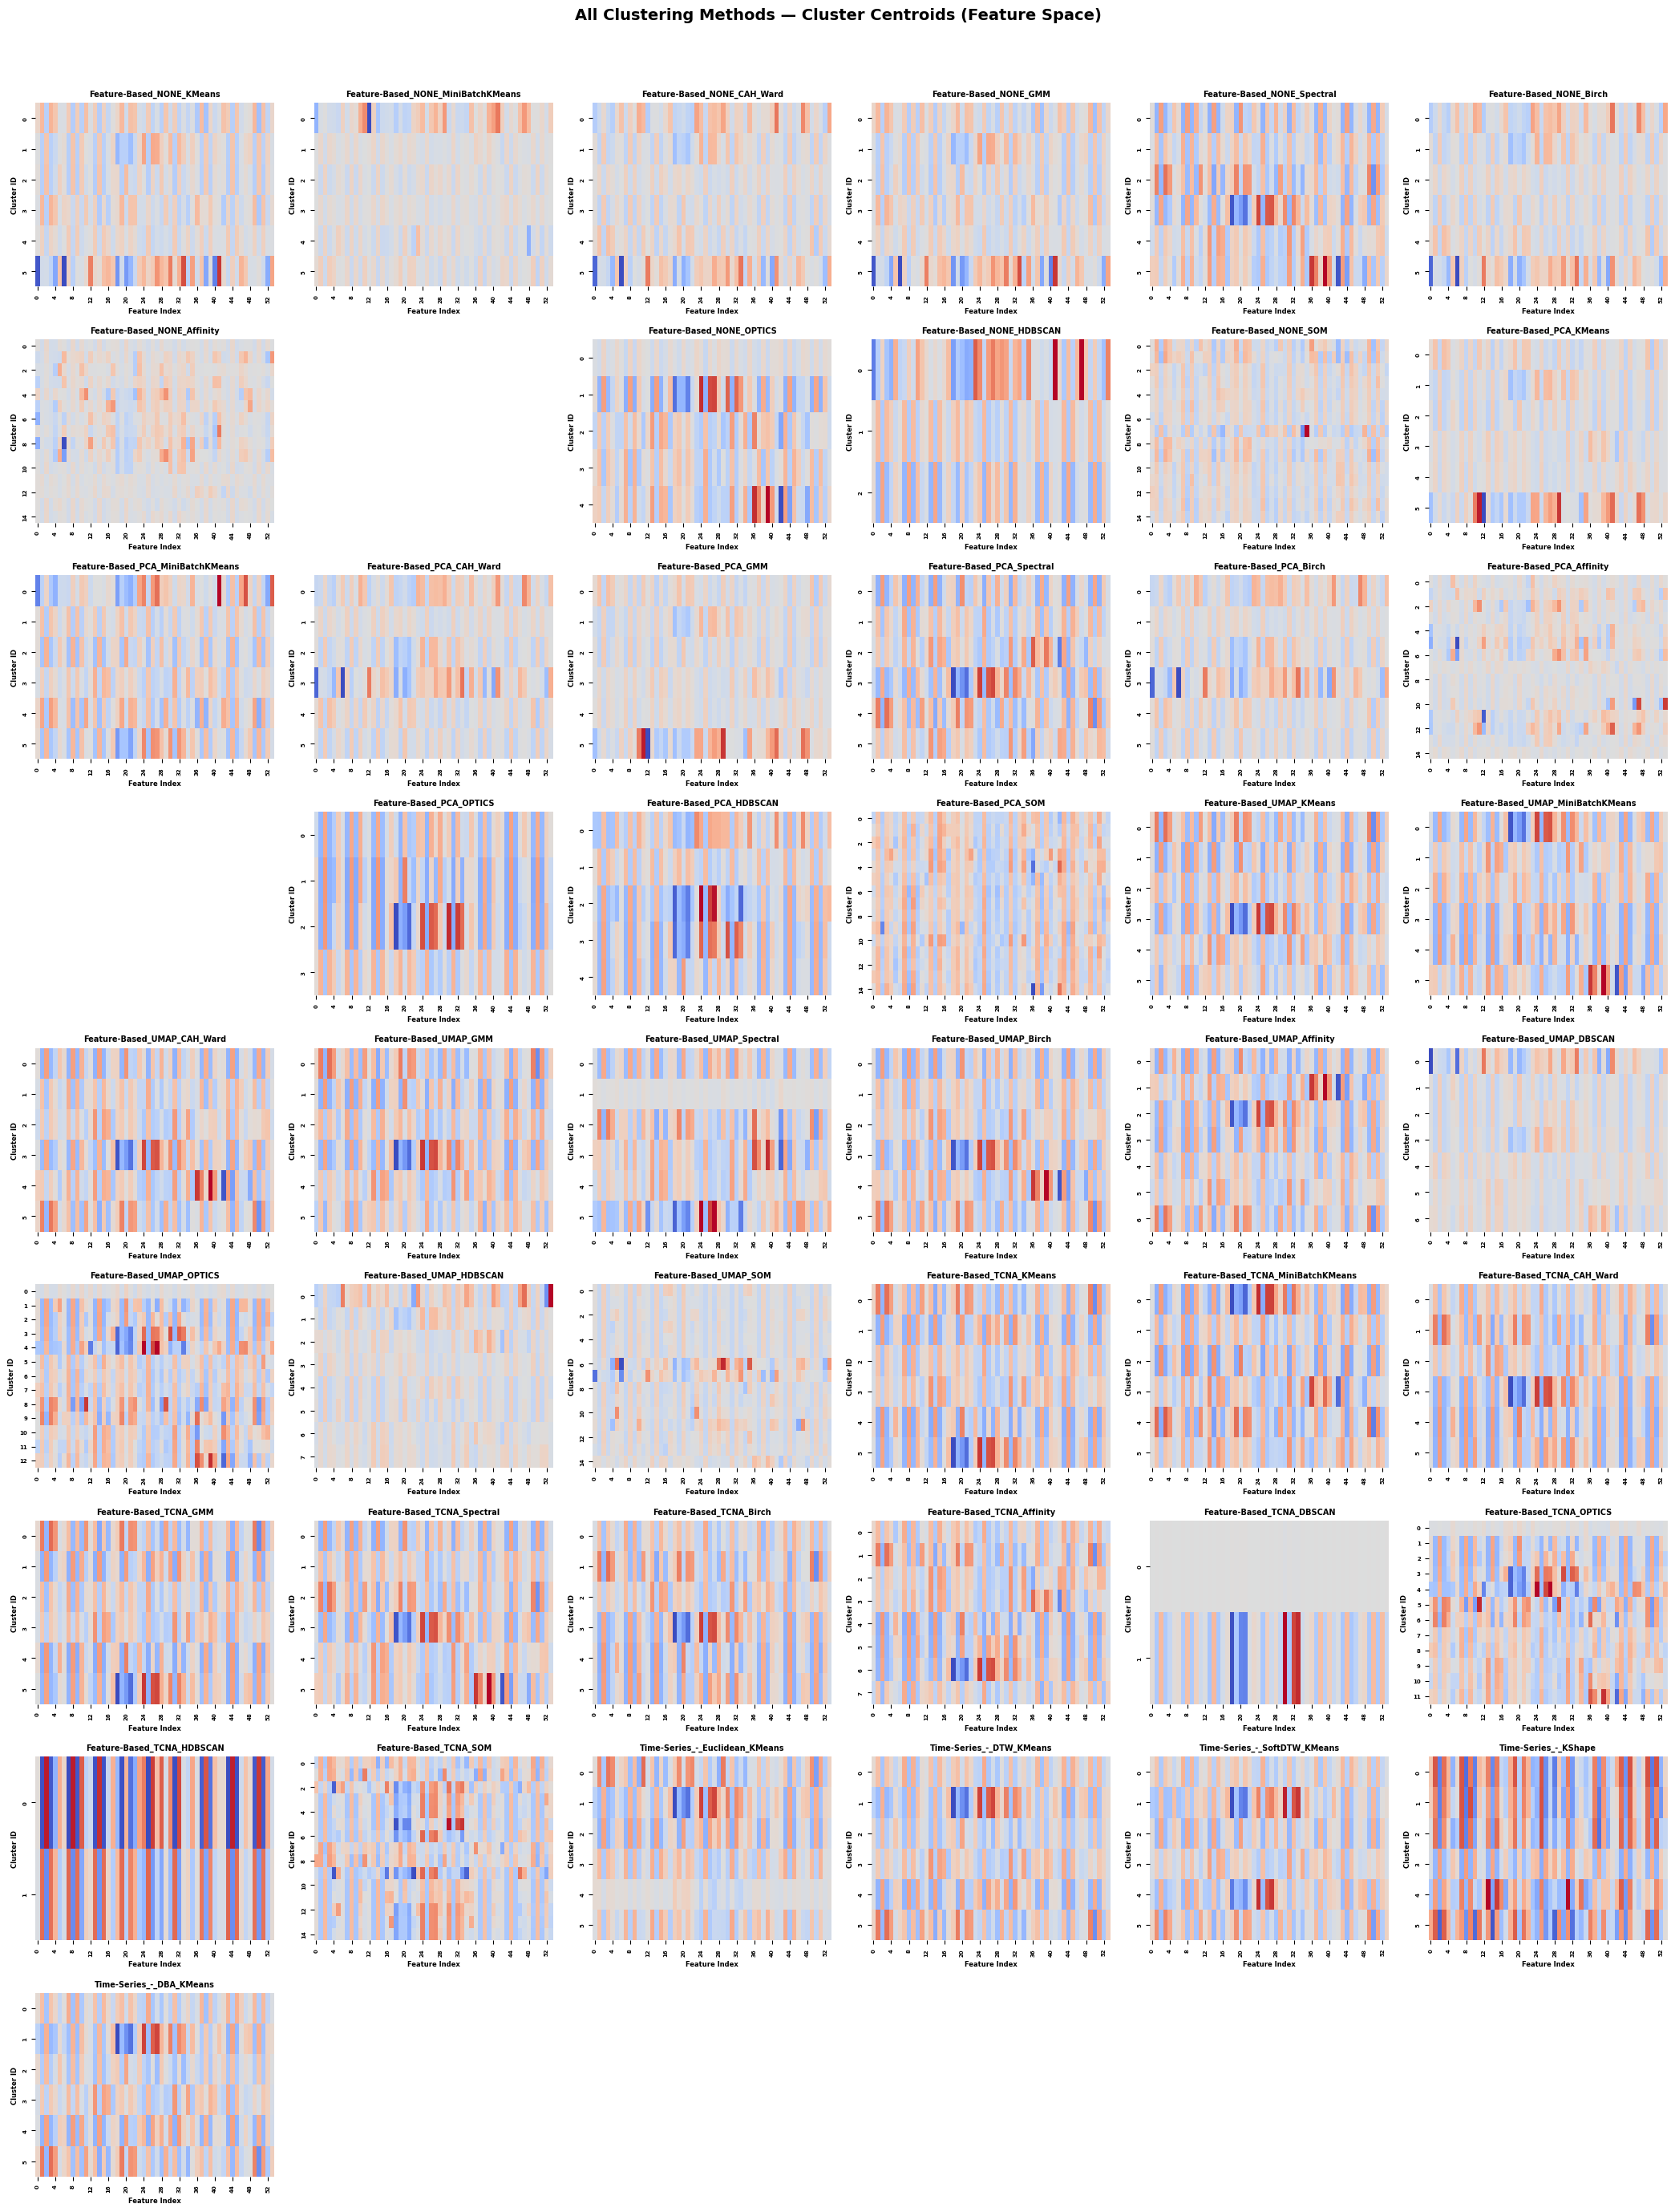

In [133]:
# ============================================================
# Parallel Visualization — Cluster Centroids for All Methods
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("📊 Generating centroid heatmaps for all applicable clustering methods...")

# --- Collect all combinations (feature + time-series) ---
all_combinations = []
for key, value in results_dict.items():
    if isinstance(value, dict):  # feature-based (with reduction)
        for subkey, sublabels in value.items():
            combo_name = f"Feature-Based_{key.upper()}_{subkey}"
            all_combinations.append((combo_name, sublabels))
    else:  # time-series
        combo_name = f"Time-Series_-_{key}"
        all_combinations.append((combo_name, value))

# --- Define layout ---
n = len(all_combinations)
cols = 6  # compact grid
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3.5 * cols, 3.0 * rows))
axes = axes.ravel()

# --- Loop over all methods ---
for i, (name, y_pred) in enumerate(all_combinations):
    ax = axes[i]
    try:
        unique_labels = np.unique(y_pred)
        if len(unique_labels) <= 1:
            ax.axis("off")
            continue

        # Compute centroids (mean feature vector per cluster)
        centroids = np.array([
            X_features[y_pred == c].mean(axis=0)
            for c in unique_labels if np.sum(y_pred == c) > 0
        ])

        # Limit visualization if >15 clusters
        if centroids.shape[0] > 15:
            centroids = centroids[:15, :]

        sns.heatmap(centroids, cmap="coolwarm", center=0, ax=ax, cbar=False)
        ax.set_title(name, fontsize=7)
        ax.set_xlabel("Feature Index", fontsize=6)
        ax.set_ylabel("Cluster ID", fontsize=6)
        ax.tick_params(axis='both', labelsize=5)
    except Exception as e:
        ax.axis("off")
        ax.text(0.5, 0.5, f"⚠️ Failed: {name}", ha="center", va="center", fontsize=7)
        print(f"⚠️ Centroid heatmap failed for {name}: {e}")

# --- Hide unused axes ---
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("All Clustering Methods — Cluster Centroids (Feature Space)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


This figure illustrates the centroid profiles of all clustering configurations, showing how each algorithm captures the average feature or signal pattern of its assigned clusters.
In the Feature-Based methods, centroid heatmaps exhibit distinct, high-contrast vertical patterns, revealing clear differentiation between activities and emphasizing dominant features such as acceleration amplitude, variance, and temporal symmetry.
Clustering models like KMeans, GMM, and Hierarchical (Ward) produce structured and interpretable centroids, whereas density-based methods yield more irregular or blurred profiles, reflecting noisier boundaries.

For the Time-Series approaches, centroids maintain smoother and periodic waveforms, highlighting rhythmic or sequential patterns across temporal variables.
Overall, this visualization confirms that both representations capture complementary dynamics:
the Feature-Based approach isolates discriminative statistical attributes, while the Time-Series approach preserves the intrinsic temporal evolution of human activities.

## 10. Pairwise Correlation Heatmap of Features

📊 Generating feature correlation heatmaps for all clustering configurations...


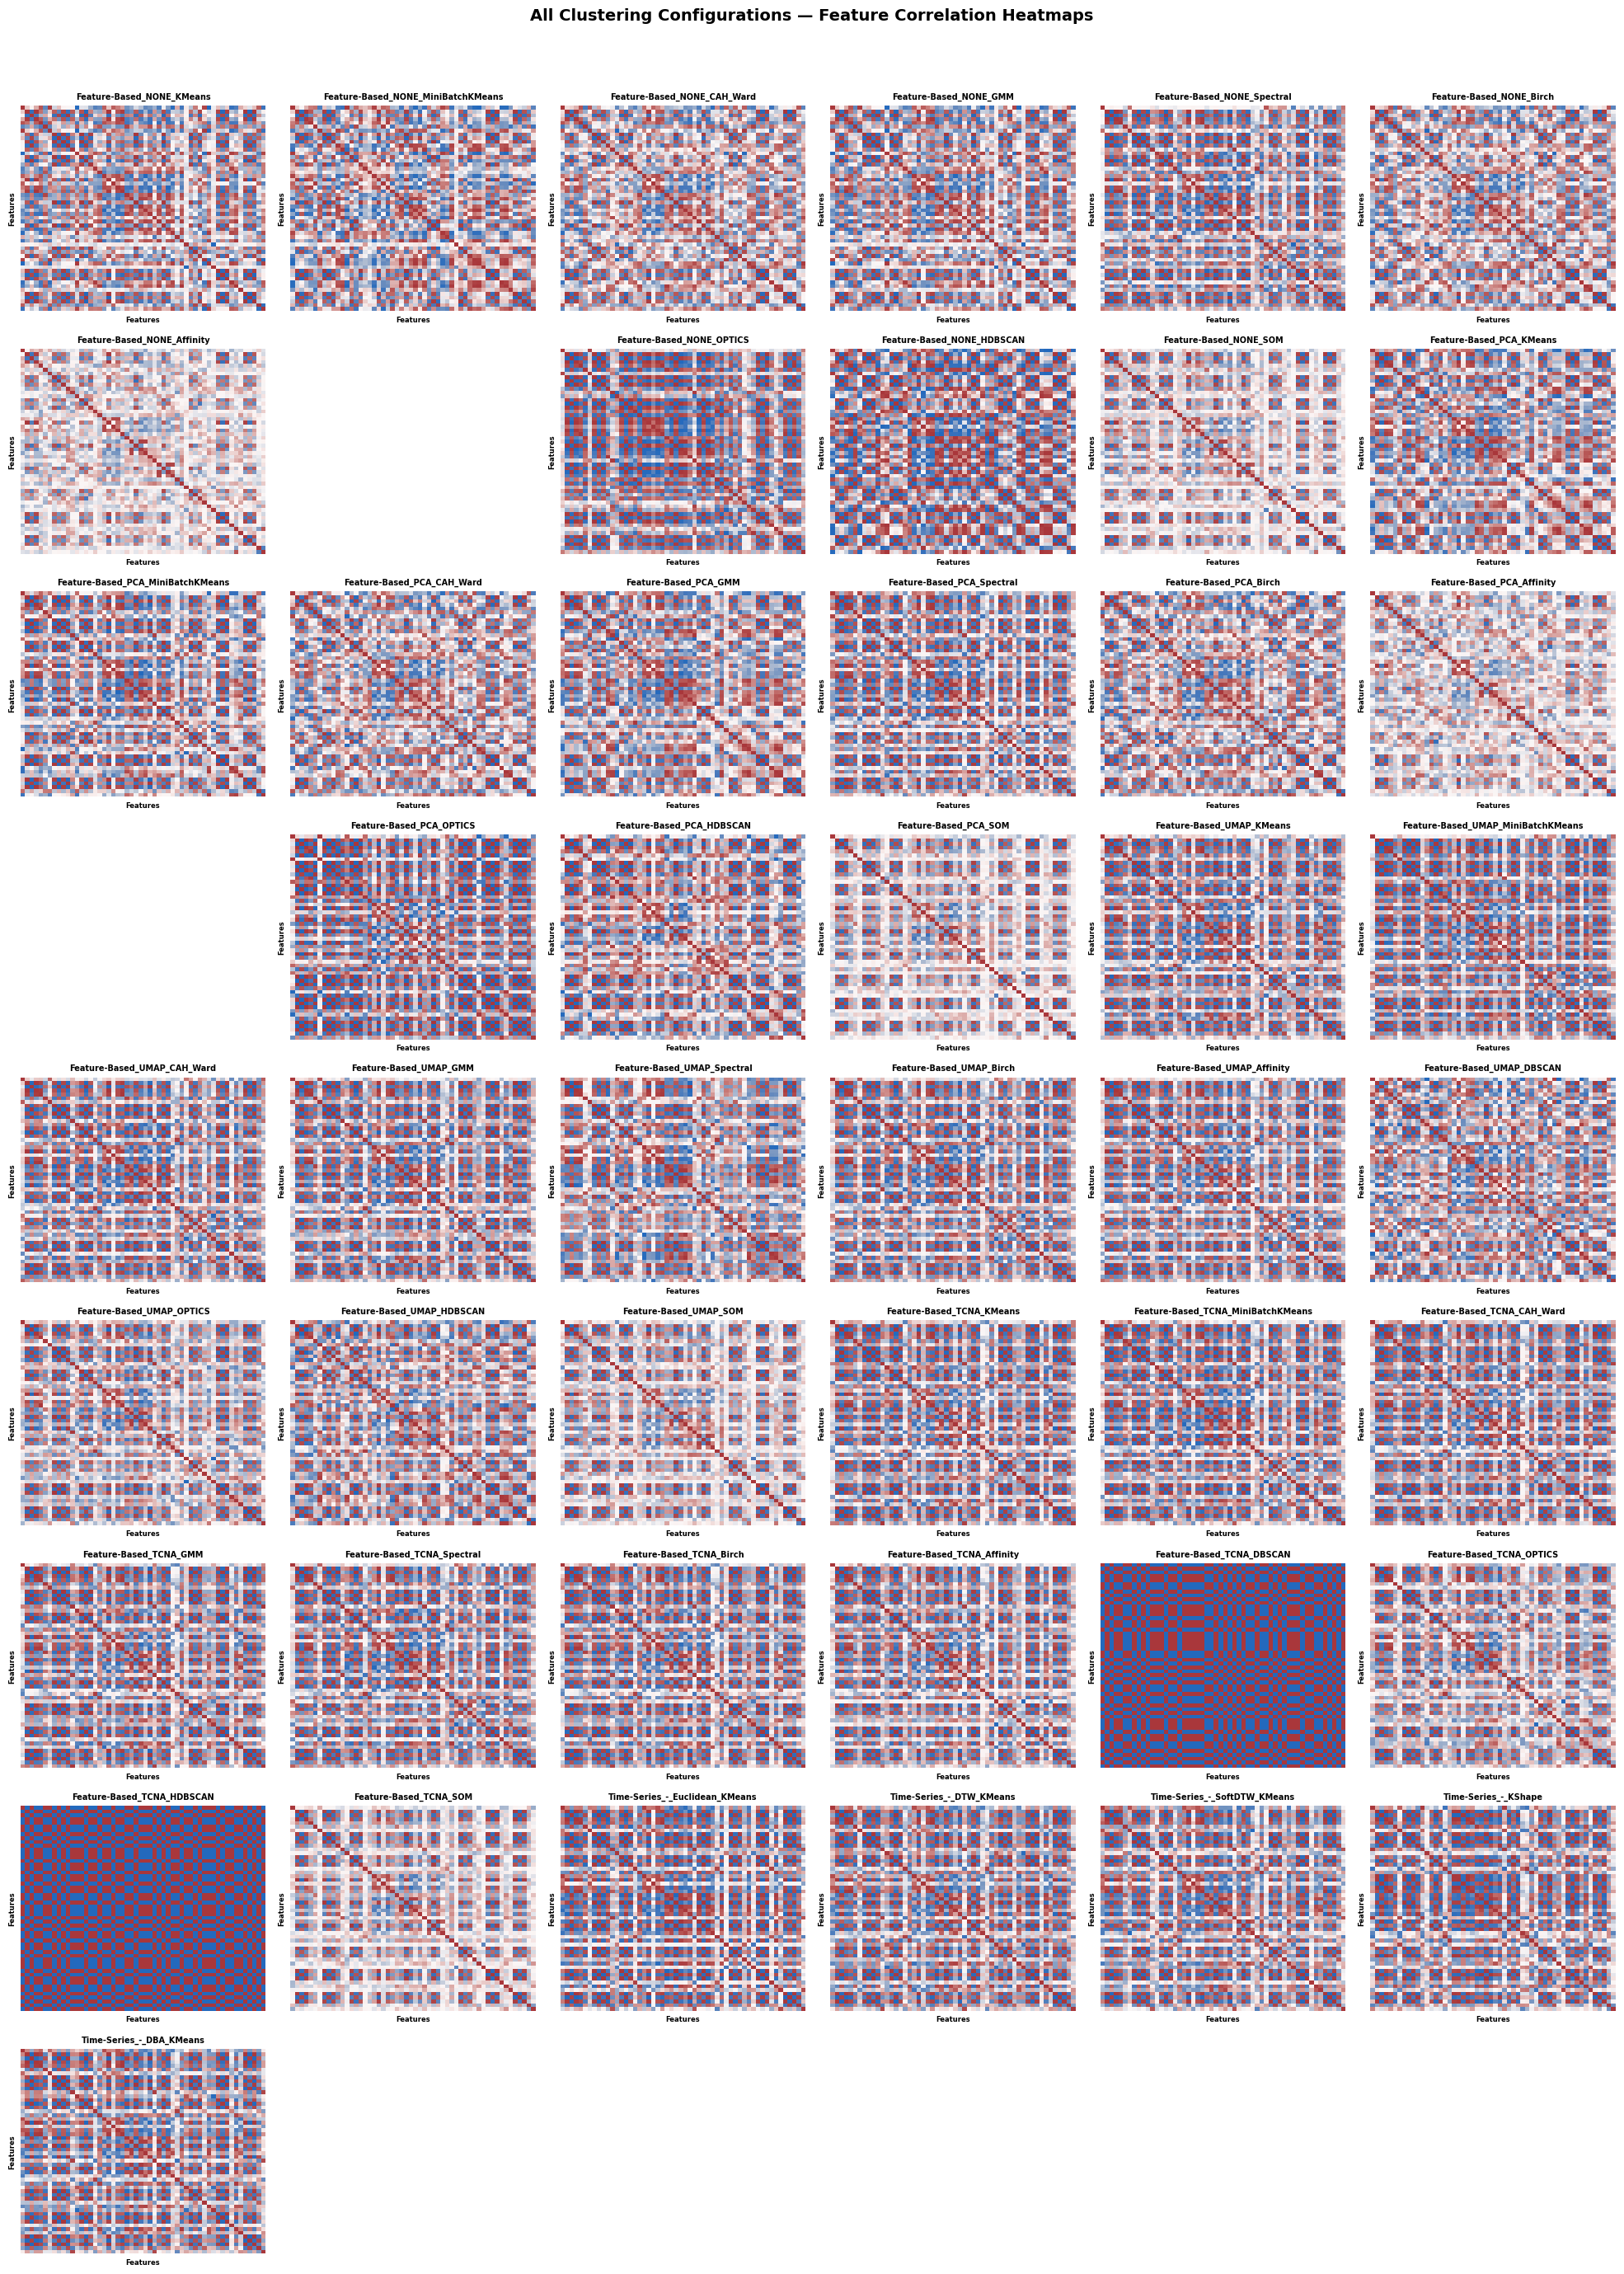

In [134]:
# ============================================================
# Parallel Visualization — Feature Correlation Heatmaps (All Methods)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("📊 Generating feature correlation heatmaps for all clustering configurations...")

# --- Collect all combinations (Feature-Based + Time-Series) ---
all_combinations = []
for key, value in results_dict.items():
    if isinstance(value, dict):  # Feature-based (with reduction)
        for subkey, sublabels in value.items():
            combo_name = f"Feature-Based_{key.upper()}_{subkey}"
            all_combinations.append((combo_name, sublabels))
    else:  # Time-series
        combo_name = f"Time-Series_-_{key}"
        all_combinations.append((combo_name, value))

# --- Prepare layout ---
n = len(all_combinations)
cols = 6  # compact grid
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3.3 * cols, 3.0 * rows))
axes = axes.ravel()

# --- Compute and visualize correlations for each method ---
for i, (name, y_pred) in enumerate(all_combinations):
    ax = axes[i]
    try:
        unique_labels = np.unique(y_pred)
        if len(unique_labels) <= 1:
            ax.axis("off")
            continue

        # Mean feature representation per cluster
        mean_matrix = np.array([
            X_features[y_pred == c].mean(axis=0)
            for c in unique_labels if np.sum(y_pred == c) > 0
        ])

        # Compute correlation across features
        corr = np.corrcoef(mean_matrix.T)

        sns.heatmap(
            corr, cmap="vlag", center=0, ax=ax,
            cbar=False, xticklabels=False, yticklabels=False
        )
        ax.set_title(name, fontsize=7)
        ax.set_xlabel("Features", fontsize=6)
        ax.set_ylabel("Features", fontsize=6)
    except Exception as e:
        ax.axis("off")
        ax.text(0.5, 0.5, f"⚠️ Failed: {name}", ha="center", va="center", fontsize=7)
        print(f"⚠️ Correlation heatmap failed for {name}: {e}")

# --- Hide unused subplots ---
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle("All Clustering Configurations — Feature Correlation Heatmaps", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


This visualization presents the inter-feature correlation structures across all clustering methods for both Feature-Based and Time-Series representations.
Strong diagonal dominance and symmetrical color patterns indicate stable intra-cluster relationships and consistency of feature dependencies across algorithms.
Feature-based models such as KMeans, GMM, and Hierarchical (Ward) reveal clear block structures, suggesting well-defined correlations among key activity descriptors (e.g., acceleration, velocity, energy).

In contrast, density-based and time-series methods display more diffuse or checkerboard-like patterns, reflecting complex or nonlinear interdependencies between variables.
Overall, these correlation maps highlight that while statistical features exhibit structured and interpretable relationships, temporal embeddings introduce richer but more entangled dependencies — confirming the complementary nature of both clustering paradigms.

### Summary of Clustering Analysis

This work demonstrates that both clustering paradigms are complementary:

The Feature-Based approach efficiently summarizes complex motion data into interpretable and well-separated clusters.

The Time-Series approach preserves sequential dependencies and better captures rhythmic or phase-shifted behaviors.

Together, they provide a holistic view of human activity dynamics, bridging statistical interpretability and temporal precision.
The results validate the methodological robustness of the dual-framework pipeline, establishing a strong foundation for future extensions, such as hybrid clustering, feature fusion, or deep temporal embeddings (e.g., autoencoders or Transformer-based clustering).
